# Wire Bond Inspection by Bidirectional Ridge Tracking

**Author:** Isai Sotarriva &nbsp;|&nbsp; **Context:** Master's Thesis &nbsp;|&nbsp; **Version:** 3.0

---

## Abstract

The visual inspection is designed to identify any defects with the produced semiconductor modules. Special attention is payed to the delicate wires connecting the silicon wafer with the flexible PCB glued on its back.

The objective of this work is to develop an automated way to find defective wire from microscope images of the modules.

---
## Notes

The current version includes some improvements devolped after my thesis presentation. A non-exhaustive list of improvements are:
- Rauch-Tung-Striebel backward pass.
- Sampling of the Gausian profile over a grid instead of only on a very narrow slice.
- Extra checks to avoid pathological cases where broken wires can still be tracked in both directions (they are saved thanks to the jump)

## Disclaimer
My original code is a whole python package and is tightly coupled with the visual inspection setup so I tasked Claude with writting a summary with some examples (simulated only since I have not permision to share the actual module photos) based on my actual project.

I read and ran the notebook but didn't edit much after this cell since it seems to reflect the project relatively well.

## Contents

1. [Introduction](#1)
2. [Setup and embedded test data](#2)
3. [Working convention](#3)
4. [Seeding with Steger's ridge detector](#4)
5. [The sequential ridge tracker](#5)
6. [Jumping gaps: the continuity test](#6)
7. [The bidirectional verdict](#7)
8. [Board-level checks: switched wires and touching wires](#8)
9. [Illustration: highlight, break and short](#9)
10. [Regression tests](#10)
11. [Development benchmark](#11)
12. [Discussion and limitations](#12)
13. [Bibliography](#13)

<a id="1"></a>
## 1. Introduction

A wire bond is a thin aluminium wire used to connects a pad on a silicon chip to a pad on the flexible PCB. After bonding, every wire must be checked and categorized into one of the follwing cases:

| Case | What it looks like | Consequence |
|---|---|---|
| intact | a continuous wire from pad A to pad B | pass (good) |
| broken | the wire is severed; the two pieces no longer line up | open circuit (reject)|
| lifted | one end has detached from its pad | open circuit (reject) |
| touching | two wires come into contact | short circuit (reject) |

**Imaging.** Under coaxial illumination on the microscope light comes staright from above the sample and then is bounced back to the microscope resulting on light backgrounds and very dar lines for the wires since they have extrmelly specular reflections.Three effects make tracking non-trivial:

* **Specular highlights.** Where the wire is locally parallel to the image plane, it reflects strongly making the otherwise black wire turn suddenly and sharply white for a couple of pixels. So the wire seems to disappear for a few pixels even though it is continuous.
* **Crossings.** The edge of the silicon wafer is tilted, almost vertical, so it reflects the light away from the objective and appears as a thin black line crossing all wires.
* **Perspective and defocus.** The wire arcs above the substrate. Seen from above, it looks curved or straight depending on its position in the field of view (camera azimuth). It is also blurred near its highest point, which lies furthest from the focal plane.

**Inputs.** For every image we have the list of wires with their *expected* start and end positions, taken from the bonding machine's program (what it was asked to do), and the wire width in pixels.

**Strategy.** Each wire is tracked twice: from pad A toward pad B, and from pad B toward pad A. For an intact wire both tracks reach the opposite pad and lie on top of each other. For a broken wire the two tracks are intermediate-length lines that never meet. For a lifted end, the track that starts at the detached pad has no wire to start on and dies immediately, while the other track does not reach it. The two directions are a safety feature: a wire passes only if both of them succeed.

<a id="2"></a>
## 2. Setup and embedded test data

The notebook is self-contained. It needs `numpy`, `scipy` and `matplotlib`, and it reads no files. The five regression test images (synthetic, 1000 × 1000 px) are embedded below as base64-encoded PNG strings. They are drawn in inverted polarity, with white wires on black. The bright vertical line in three of them plays the role of the silicon edge, which is a black line in a coaxial image.

In [31]:
import base64
import io

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, map_coordinates, zoom
from scipy.spatial import cKDTree

plt.rcParams.update({'figure.dpi': 100, 'font.size': 9, 'axes.titlesize': 9})
print('ready')

ready


{'test1': (1000, 1000), 'test2': (1000, 1000), 'test3': (1000, 1000), 'test4': (1000, 1000), 'Test5': (1000, 1000)}


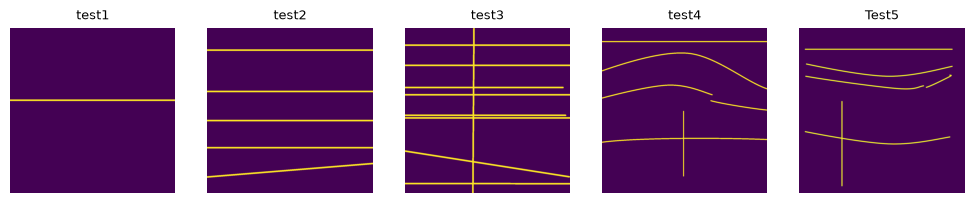

In [32]:
# Regression test images: 8-bit greyscale PNG, base64-encoded (about 30 kB in total)
TEST_PNG = {
    'test1': (
        'iVBORw0KGgoAAAANSUhEUgAAA+gAAAPoCAAAAABoyIs4AAAD9ElEQVR42u3TAQ0AAAjDMMC/Z3CAgKeVsGRVAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAQK5eDSDeSABGB4wOGB0wOmB0wOiA0QGjAwAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAfA4z'
        'jAETyw+euAAAAABJRU5ErkJggg=='
    ),
    'test2': (
        'iVBORw0KGgoAAAANSUhEUgAAA+gAAAPoCAAAAABoyIs4AAAFVUlEQVR42u3dMU4EQRAEwZ0V///y4GKch4RQVsQTujs16xw8DwAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAMCvnWsGkPcaAQgdEDogdEDogNABoQNCB4QO'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAACfnGsGkPcaAQgdEDogdEDogNABoQNCB4QOAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAC7zjUDyHuNAIQOCB0QOiB0QOiA0AGhA0IHAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAD4O+eaAeS9'
        'RgBCB4QOCB0QOiB0QOiA0AGhAwAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA/E/HCKDrCh3acXvRod+20GEhbqHDQNxCh37bQoeFuIUOA3ELHfptCx0W4hY6DMT9'
        'M3ChQzRuLzr02xY6LMQtdBiIW+jQb1vosBC30GEgbqFDv22hI+61P94mdMQ9UJnQ0fZAWEJH3AMxCR1xDwQkdLQ90IzQEfdAJ0JH'
        '3ANtCB1xD/QgdLT9+CeLIG6hg7iFDtoWOuJ20caCuF2xEbEct8M1LzzcmB3iFjqIW+ho2x0KHXG7PaEjbtM3eLSNLSBubARxYzva'
        'dj1CR9wuRuiIG6GjbYSOuBE64saexW3nWLq47RkH4KscHIO4ETq+yhE6Hm6ELm6rQujith2ckocbnJW4wYmJG+bPTdwIXdsGjNDF'
        'LW6ELm4QurbBsYob1g9X3NA8Ym1D9KLFDdHrFjc0L13bED17cUM0AT/lhmjo4oZm6L7KIRq6uCEaurihGbq2IRq6uCEaurghHPrV'
        'NuR9iRuELm4QurhhJ3RtQzR0cUM0dHFDM3RtQzR0cUM0dHEDAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAl3wLVVr751OFiAAAAAElFTkSuQmCC'
    ),
    'test3': (
        'iVBORw0KGgoAAAANSUhEUgAAA+gAAAPoCAAAAABoyIs4AAALTElEQVR42u3dMW4cOxAAUVLQ/a/cDmzYgmA48A4WM6z3Ikc/ILvQ'
        '/LsStBd3Nr//tR0G/+/DETyDzhE6IHQQOiB0QOiA0FkXfbsGQgeEDkIHhA4IHRA6IHRA6IDQAaEDQgehA0IHhA4IHRA6IHRA6IDQ'
        'QeiA0AGhA0IHhA4IHRA6IHQQOiB0QOiA0AGhA0IHhA4IHRA6CB0QOiB0QOiA0AGhA0IHhA5CB4QOCB0QOiB0QOiA0AGhg9ABoQNC'
        'B4QOCB0QOiB0QOiA0EHogNABoQNCB4QOCB0QOiB0EDogdEDogNABoQNCB4QOCB2EDggdEDogdEDogNABoQNCB4QOQgeEDggdEDog'
        'dEDogNCBb/Y4A7DRAaEDQgeEDggdEDogdEDoIHTgJNsR3Nm4KGx0QOiA0EHogNABoQNCB4QOCB0QOiB0EDogdEDogNABoQNCB4QO'
        'CB2EDggdEDogdEDogNABoQNCB4QOQgeEDggdEDogdEDogNABoYPQAaEDQgeEDggdEDogdEDoIHRA6IDQeYPtCBA6IHQQOiB0QOiA'
        '0HnJOAKEDggdEDoIHRA6IHRA6IDQAaEDQgeEDkIHhA4IHRA6IHRA6IDQAaGD0AGhA0IHhA4IHRA6IHRA6IDQQeiA0AGhA0IHhA4I'
        'HRA6IHQQOiB0QOiA0AGhA0IHhA4IHYQOCB0QOiB0QOiA0AGhA0IHhA5CB4QOCB0QOiB04Fp7nAHY6IDQAaEDQgeEDggdEDogdBA6'
        'cJLtCG5s3BM2OiB0QOggdEDogNABoQNCB4QOCB0QOggdEDogdEDogNABoQNCB4QOQgeEDggdEDogdEDogNABoQNCB6EDQgeEDggd'
        'EDogdEDogNBB6IDQAaEDQgeEDggdEDogdBA6IHRA6IDQAaEDQgeEDggdEDoIHRA6IHRA6IDQAaEDQgeEDkIHhA4IHRA6IHRA6IDQ'
        'AaGD0AGhA0IHhA4IHRA6IHRA6IDQQeiA0AGhc6ntCBA6IHQQuiMAoQNCB4TOS8YRIHRA6IDQQeiA0AGhA0IHhA4IHRA6IHQQOiB0'
        'QOiA0AGhA0IHhA4IHYQOCB0QOiB0QOiA0AGhA0IHhA5CB4QOCB0QOiB0QOiA0AGhQ9IeZwCP7ddGh/PNCB0KqQsdEDoIHTjo7S50'
        'WOd/8C508HQHTvgmXegQ+ImZ7ajWAz5mcU14ugNCB4QOQgeEDggdEDogdEDogNABoYPQAaEDQgeEDggdEDogdEDoIHRA6IDQAaED'
        'QgeEDggdEDoI3RGA0AGhA0IHhA4IHbjIHmcANjogdEDogNABoQNCB4QOCB2EDpxkO4L7GteEjQ4IHRA6CB0QOiB0QOiA0AGhA0IH'
        'hA5CB4QOCB0QOiB0QOiA0AGhg9ABoQNCB4QOCB0QOiB0QOiA0EHogNABoQNCB4QOCB0QOiB0EDogdEDogNABoQNCB4QOCB2EDggd'
        'EDogdEDogNABoQNCB4QOQgeEDggdEDogdEDogNBPtB0BQgeEDggdhA4IHRA6LxlHgNABoQNCB6EDQgeEDggdEDogdEDogNBB6IDQ'
        'AaEDQgeEDggdEDogdBC6IwChA0IHhA4IHRA6IHRA6IDQQeiA0AGhA0IHhA4IHRA6IHQQOiB0QOiA0AGhA0IHhA4IHYQOCB0QOvAA'
        'e5wBnJKzjQ7nmxE6FFIXOnRLFzosn7oDQgeEDggdWG/5Kl3oEPiRme1o1v2/KHFLeLoDQgeEDkIHhA4sv48O2OiA0AGhA0IHhA5C'
        'B4QOCB0QOrDu86cdWH4fHRsdEDogdEDogNABoQNCB6EDQgeEDggdEDogdEDogNBB6IDQAaEDQgeEDggdEDogdEDoIHRA6IDQAaED'
        'QgeEDggdEDoIHRA6IHRA6IDQAaEDQgeEDkIHhA4IHRA6IHRA6IDQAaEDQgehA0IHhA4IHRA6IHRA6IDQQeiA0AGhA0IHhA4IHRA6'
        'IHQQOiB0QOiA0AGhA0IHhA4IHRA6CB0QOu+xHQFCB4QOCB2EDggdEDogdP5tHAFCB4QOCB2EDggdEDogdEDogNABoQNCB6EDQgeE'
        'DggdEDogdEDogNABoYPQAaEDQgeEDggdEDogdEDoIHRA6IDQAaEDQgeEDggdEDoIHRA6IHRA6IDQAaEDQgeEDkJ3BCB0QOiA0AGh'
        'A0IHhA4IHRA6CB0QOiB0QOiA0AGhA0IHhA5CB4QOCB0QOiB0QOiA0AGhg9ABoQNCB4QOCB0QOiB0QOiA0EHogNABoQNCB4QOCB0Q'
        'OiB0EDogdEDogNABoQNCB4QOCB2EDggdEDogdEDogNABoQNCB4QOQgeEDggduJXPWWs7Bjg89LXW/Pyn3uHk0H8ZucP5oX/NXe9w'
        'dOjWO3RClztkQveah0zo1jt0Qpc7ZEL3mofn2X+qfem/weXGAXNp6N/nSu9C59jQL+rdUAqdB4Qud6GTCd1rXuhkQrfehU4ndOtd'
        '6GRCl7vQyYTuNS90OqFb70InE7r1LnQ6octd6GRC17vQ6YQud6GTCd2HdUInE7r1LnQ6octd6GRC95oXOpnQrXeh0wndehc6mdDl'
        'LnQyoXvNC51O6Na70MmEbr0LnU7ochc6mdDbvQudVujR3IVOMfTch3VCpxt6aL0LnXzohdyFjtADr3mhI/TAehc6Qg+sd6Ej9EDu'
        'o3OEfv5rXugIPbDehY7QA+td6Ag9kLvQEXqgd6Ej9PNz9+0aQg98WCd0hB5Y70JH6IHchY7QA695oSP0wHoXOkIPrHehI/RA7kJH'
        '6IHXvNARemC9Cx2hB9a70BF6IHehI/RA70JH6IHchY7QAx/WCR2hR3p3Rwjdd3FgiOQOxsdvvSN0rHeEjvWO0JE7QsdrHqHr3X0i'
        'dLm7VYyE2F0uZqH387OuGFPwjNC3D+tw/ZHQ/d87Lr4Tutxx5ZnQffWOu86Ebr3jljuhW++43kzo1jsuthO63HGlmdC95nGXmdCt'
        'd9xiJ3S54/4yoetd6HRCl7vQyYTuwzqhkwndehc6ndDlLnQyoXvNC51M6Na70OmEbr0LnUzo1rvQ6YQud6GTCd1rXuhkQrfehU4n'
        'dLkLnUzoXvNCJxO69S50OqFb70InE7rchU4mdK95odMJ3XoXOpnQrXeh0wndehc6mdCtd6HTCV3uQicTute80MmEbr0LXei1O5K7'
        '0IUud1PtSISud7PtMIRuvQsdoctd6Ajda17oCN16FzpCt96FjtCtd6EbYHckd6ELHa95oQtd7qowRELXe6UNQyR0uQcKMURCl3sg'
        'FEMkdL0HcjFEQpd7oBpDJHQnHGjHEAndOQcKMkRCJ/CaN0RCJ7DeDZHQCax3QyR0ArkbIqETeM0bIqETWO+GSOgE1rshEjqB3A2R'
        '0Am85g2R0Amsd0MkdALr3RAJncB6N0RCJ5C7IRI6gde8IRI6gfVuiIROYL0bIqETyN0QCZ3Aa94QCZ3AejdEQiew3g2R0AnkboiE'
        'TuA1b4iETmC9GyKhE1jvhkjoBNa7IRI6p+e+DZHQKeS+P50erEf9AbXxk3E2Otb739jo8OD1PkIHr3mhQ2i9Cx3OX+8+dYfz1/u2'
        '0eH43LenOxRe8+vDUcD5hA5CB4QOCB0QOiB0QOiA0AGhg9ABoQNCB4QOCB0QOiB0QOggdEDogNABoQNCB4QOCB0QOgjdEYDQAaED'
        'QgduYY8z4A5/1xehA57ugNABoYPQAaEDQgeEDggdWH4u6Wzjir4eAi/6dARYQ57ugNABoQNCB4QOCB0QOiB0EDogdEDogNABoQNC'
        'B4QOCB2EDggdEDogdEDogNABoQNCB6EDQgeEDggdEDogdEDogNABoYPQAaEDQgeEDggdEDogdEDoIHRA6IDQAaEDQgeEDggdEDoI'
        'HTjdD9haVFzW9RymAAAAAElFTkSuQmCC'
    ),
    'test4': (
        'iVBORw0KGgoAAAANSUhEUgAAA+gAAAPoCAAAAABoyIs4AAAM1klEQVR42u3dy24jNxRFUV3D///LzCBBI0CjH5BUJfKctQaZRk3e'
        'Lapku+rxAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAgDeYZQ0g3pclAKEDQgeEDggdEDoAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAQaSzB8Zatx27r2iBgf5vjNhFCp6pukyF0qvo2H0Knpm9TInSKCjcqQmePwOfWF2BehM4thc/nX5ShETpX'
        'JD77vUaDI3TeU/hs/5JNj9B5MvE57OWbIKFLPGQnliESOq8lPhn/KoMkdI3nLP0yTEKXeMmaL/MkdI13rLbYha7xkmVexkroEu9Y'
        '4GWyhN7d+NSvh+ESenTjY2HMl9CjIx/rY0mEnty4ldS60DXevmDWSOgnR279tC50jVs/ayb0cyO3aloXusb57XJaQqFvHbm10rrQ'
        'NY7WhS5yi2xhhe4eSVpH6G6NFLvk1lnoItc6Qhe51BG6extqncb1FbnUhS5ytC50kXPL1tgPob87cjMldaGLHK0LXeRIXegiR+pC'
        '96QgtC50kUvdtgld5EWt2zyhi1zqeFa3EZE6GYsocq2THrqHc0ud8NBFLnXSQ1e51AkPXeTdrdvlgtBFLnV7nR66yqVuw8NDF7nU'
        '7Xt66EvkSD08dJXjE3x46CJH6umhqxyph4cucqSeHrrKkXp66EvkSD07dEc5Uk8P3VGO1NNDVzlSDw9d5Eg9PXSVI/X00FWO1NND'
        'XyJH6tmhO8qRenroKkfq6aH7wM5Ns2WmPlaZypF6eugqR+rhobssR+rpoTvKkXp66CpH6umhqxypp4eucqSeHrrKkXp66EvkbJj6'
        'CF3lSF3oPrDj87vQVY7UO0JXOVJPD13lSD09dJUj9fTQVY4v4NND94M0pJ4eusrx+T09dJUj9fTQVY7U00NXOS7V00NXOVJPD13l'
        'SD09dJUj9fTQVY5v5dJDVzkO9fTQVY7U40NfKkfq4aGrHJfq6aGrHId6eugqR+rpoascqadO/KgcqeeP/agc8ksflUN+6rNkDvGp'
        '/xy6ypF6XAjj/piQn/r/Q1c5Sg8t/UfoKofc1P8NXeUQnfoslcNvUs/oQ+VQcKgLHQpSFzoUpC50KLhUFzoUHOpCh4LUhQ4FqQsd'
        'Ci7VhQ4Fh7rQoSB1oUNB6l+2EN5yX3QnOjjUhQ5SFzpI3TU6uFR3ooNDXehQkbrQoeC3YoUOBYe60KEgdaFDQep+vAYFP2pzokPB'
        'oS50KEhd6FDwozahQ8GhLnQoSF3oUJC60KHgUl3oUHCoCx0KUhc6FKTuV2Ch4LdinehQcKgLHQpSFzoUpO4aHQou1Z3oUHCoCx0K'
        'Uhc6FKTuGh0KLtWd6FBwqAsdClIXOhSk7hodCi7VnehQcKgLHQpSFzoUpC50+ETpN6cndCg41IUOBakLHQpSFzoUpC50KPhWTuhQ'
        'cKgLHQpSFzoUpC50KEhd6FDwrZzQoSB1oUNB6kKHgkt1oUNB6kKHgs/vQoeC1IUOBakLHQpSFzoUpC50KEhd6FCQutChIHWhQ0Hq'
        'QoftS3+9U6FDQepCh4LUhQ4FqQsdClIXOhSkLvSN99SW8a7UTc32YdtCg/L6lpuSI+O2m1I3GnV921apm4imvm2v1E1CU+A2Wepm'
        'oCZwe50/YGPzTyt87vmf2fHK1G375wqfz70E296Wuh2/ufDZ5zXZ+6KLdZsdeYIutTvW7fNthc8hr9gUxKdui69IfA589SYhOnXb'
        '23PZu9SeP51jZy9NfHL+VUYi8Vi3qy82PpH/QGORdqzb0d6vq5fYe1K3m+U/kVpiD93GsZPPNj6V/34jktD6WB0/e/rzSoj99NTH'
        'qrhS/as10frRrY/VMNp/vTpiP3P7pm/r3Gj1xWXS+rGtG15zLPbW35jTOFr35OWsxk3tMwto1U7audE4T6+k1Ttm40bjONjzN24a'
        'GzebDva2fRuNo/X8fZueyM3itUttfR9u6q9xrSN0jWsdoT8ZuZn7zBZYd6FrXOsI3Yd1rSN0B7nWyQ5d41onPHT3JtY62aE7yLVO'
        'eOgO8qDWbZbQPVtA6/SF7iDXOuGhO8i1TnboDnKtEx66g9y9hwkPXeSOdcJD93A/rZMduoNc6/Y5PHSRa912h4fu07rWbXt46CLH'
        '1/DhoYscx3p26BpH6+Ghixyth4cucrQeHrrI0Xp46EvjuClNdugiR+vhoYscH+HDQxc5VwyR0dkodJFzVevGZ5PQRc6VrRuhDUIX'
        'OVe3bow+HLrIuaF1k/TJ0EUO4aGLHMJDFzmEhy5ySA99iRyyQxc5hIcucggPXeQQHrrIIT30JXLIDl3kEB66yCE8dJFDeugqh/zQ'
        'l8gh3rfIoTB0kUN46CKH9NBVDuGhixwehU/DAQAAAAAAAAAAgEfd89Hh4YHJQoeXfiXbbAqdkr+9MJ9Cp+SPrMyo0Cn5a0pzKnRa'
        '/m7asAqdklskGFih03I/FFMrdErufWRyhU7Ljc6Mr9BROxaJrHuYGmTrQ8sNi02zpUHtQgexCx1OfPKI4bYWqF3okPVQMWNuBVC7'
        '0CHsgaEjdFC70CHrYeAjdFC70EHuQocTa0+uQeiovSAJoSP3gjCEjtoL8hA6ci+IROiovSAVoUNB7kKHgtyFDs/VflQ8QoeC3IUO'
        'BbkLHd6W+749CR0Kchc6FOQudLgy900SEzrckPunSxM6FOQudLg79w9kJ3Qo6F3oUJC70KGgd6HDRrlflaTQoaB3ocO+ub8tUKHD'
        '/r2/HKrQoaB3ocNpuT/RrdChIHihw/G9/7ljoUNM778OWuiQ1/tPZQsdkoP/L3GhQ98BD/gNO8BDpIA9gxc6FBQvdCgoXujgOh6A'
        'w97bvbm38tG97SOcHa/0ZQlA6IDQAaEDQgeEDggdEDogdBA6IHRA6IDQAaEDQgeEDggdhA4IHRA6IHRA6IDQAaEDQgehA0IHhA4I'
        'HRA6IHRA6IDQAaGD0AGhA0IHhA4IHRA6IHRA6CB0QOiA0AGhA0IHhA4IHRA6CB0QOiB0QOiA0AGhA0IHhA4IHYQOCB0QOiB0QOiA'
        '0AGhA0IHoQNCB4QOCB0QOiB0QOiA0EHogNABoQNCB4QOCB0QOiB0QOggdEDogNABoQNCB4QOCB0QOggdEDogdEDogNABoQNCB4QO'
        'QgeEDggdEDogdEDogNABoQNCB6EDQgeEDggdEDogdEDogNBB6IDQAaEDQgeEDggdEDogdBA6IHRA6IDQAaEDQgeEDggdEDoIHRA6'
        'IHRA6IDQAaEDQgeEDkIHhA4IHRA6IHRA6IDQAaGD0AGhA0IHhA4IHRA6IHRA6IDQQeiA0IFTjCWosGIHeBlioWsTVQhdtrS0JHT9'
        'UtCd0HVMwZvBSBny3whGz5D/HjCKrtnxFf/WbvN/6du2+q7GsuWP17eoZcv7dm0JPS9rAfP8TKzC0JeQ8ZZwZRff3WVLmYPfC9Z+'
        'oS89w41zvW4LfSkaNnkT+D62bU3DnR/dl6ohNPQlawgNfQkbYkNfyobU0JeyITf0pW3IDX2JG3JDX+KG+NCXusG37vKGitDlDbmh'
        '6xtyQ9c3BIcucEgOXeEQ70vnUBC6JQChA0IHhA4IHRA6IHRA6IDQQeiA0AGhA0IHhA4IHRA6IHQQOiB0QOiA0AGhA0IHhA4IHYQO'
        'CB0QOiB0QOiA0AGhA0IHhA5CB4QOCB0QOiB0QOiA0AGhg9ABoQNCB4QOCB0QOiB0QOggdEDogNABoQNCB4QOCB0QOiB0EDogdEDo'
        'gNABoQNCB4QOCB2EDggdEDogdEDogNABoQNCB6EDQgeEDggdEDogdEDogNABoYPQAaEDQgeEDggdEDogdEDoIHRA6IDQAaEDQgeE'
        'DggdEDoIHRA6IHRA6IDQAaEDQgeEDggdhA4IHRA6IHRA6IDQAaEDQgehA0IHhA4IHRA6IHRA6IDQQeiA0AGhA0IHhA4IHRA6IHRA'
        '6CB0QOiA0AGhA0IHhA4IHRA6CB0QOiB0QOiA0AGhA0IHhA5CB4QOCB0QOiB0QOiA0AGhA0IHoQNCB4QOCB0QOiB0QOiA0EHogNAB'
        'oQNCB4QOCB0QOiB0EDogdEDogNABoQNCB4QOCB0QOggdEDogdEDogNABoQNCB4QOQgeEDggdEDogdEDogNABoYPQAaFzvvnxHwAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAACq/AOvo0DQN6FNBgAAAABJRU5ErkJggg=='
    ),
    'Test5': (
        'iVBORw0KGgoAAAANSUhEUgAAA+gAAAPoCAAAAABoyIs4AAAvAklEQVR42u3df3Ab533n8YcUKUESCII0f4AAiaUAQuSSXMMcRIfQ'
        'ruLYddurk7STSz1J616m1/Hl2szVk8mkuWubTJqmTdO002kzuZynzfTc9pI2vvbaS5PmcmniKmrMsAxMw0t4SYIAuSAAgj9EUhBE'
        'wRJF3h9UbEESgQXFH/jxfv0RmtSCIRf74fe7u88+jxAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAUNZqDGzy/ve0'
        'Hbt57KY4dpMPfODD4X1Yee5rhxj0L/wyfw+BI/GBPz20oCuvsruBo7HecnN/vlFtwS0eZG8DR8TqFYcV9DX2NnBU9EML+jdfY28D'
        'R+PPLx1a0G/+5LfZ38ARuP4//pM4vKvuQjSaa7dqt0TtFh/4wIfD+7B+lT92AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAKC01xjdteqJ2cewquwyoZE+ubW9v3wj+t1/01rMzgAqt6E1R6w//Mzs6EgjMsu+AyvPUdq6Fr37y8QfYLUBl'
        'ee/2PUz99a88fJp9A1RM626LnNrlX155aWz8tRvsSqASPH1te3eXv/v775dq2ElA2d9e637nW3yD+TZYf3FcHVlknwLlHHQhhGjy'
        'nh8458q3RTx4MRBcZscCZRx0IYQQkve84mvJt8V0YHyMsTVAWQddCCFqeob9b+035dvklfGxQIi0A2UcdCGEEPVD54b8fXV5ttic'
        '/G7g1SCX5IEyDroQQojGIf9Q/tP26+OjgcDkTXY2UL5BF0II0TFwfvicNd8WG+royFh0mz0OlG/QhRBCeHx+r/9Uvi3SgdEgaQeM'
        'nBh7H1z95rVSDLoQQtT0e/1+X77TdrEaHA0E5kg7sGuHfH7o/NApIWI/PlWiQd/5W3TOO/h4T/60j4+NjcVJO3DnFe5hv/+Na14T'
        'SikHXQghxMlzXt8j3XnTvjIeHBvjeVdgR9Pw8CN3nPz2a6Ue9Fsj6XzDytm8m6RHQiN08qhyNT3D/sf77v76Q8GyCPqtS/K+87Ir'
        'f9oDAfVijDtwqEYnfY8Mn2++5z/NnRHlE3QhhBAO5Zzf25l3k43R0Pe0V6ntqCIdQ+fPP7Lrv66/46VyC/pO2v0Dfn9L/tqujagB'
        'Hm9HFXTrfcNvG85zXpt6cfSFBVGWQRdCCHFG8fl8trybbAYCEwH1GscCKtSxwbc/5t89BBuB7wUvJkp1wExRtX3Y61cKpH0yOKry'
        'DBwqzelz588Pm3f959hF9f/OXC3lkXGi+OddfY/I9vzbTGjB0dACRwcqgsP/qN+fr5O9+L35kh8Cuzdd57y+oQJpj2qBgMoNd5T5'
        'DbTH/X27/vP69y6OjV4ti7Hu96Hd7/MVuCYvUlogoE5zmQ6iDIe7+R/17358R0f+KaCWz0Mt993WeM8NebsLbDQ6MaYGXufQQblo'
        'PPfY8GO7/uv1seDF/b3sVvpBF0II0Tqk+JW+AhtNj6jayBrHEEpc+/lHf+ShXf91dfSC+uK18ntMdT//CMrnPYN1+TeKBwMBbYbx'
        'NSjNbv3s2/yP7t6fpi6OfGfiZnk+j77PTg/4Fd/g8fwbrYeCo5PccUdJOTn8yHlf8+4N6YXvX4iI8p144iAc63t40K+cEgXuuAfU'
        '0DgzyqMEOM6f9z6S5wbaiyPfuyTKe4aZg/shu8/L/iGrKNTKa4FAlAdjcHTD3d76qH/3p7fSoxdGR65WwFRSB6zDryjDBW7Biexk'
        'YDykXuKgwyF36/5HH8kz3C1+cWTkSGdDLrf10hr8Xp9y9nih4h4ITAWYmw6H48y5Rx9+KM/gzu+MXpwXFTQ55OH99VQGffKwqcBW'
        'aXV6fFy9zHGIg3PCN+zP02ZujI5dKI37wOW7AmpNt88n+22FNkuOa6NTk4yng9j/4ZzDj/nzjOQcGb04fq0Sp3s+Cq3nlKHevkLF'
        'XYy+qmmjjLCB2LenTL2Pde/+79P/FLhYWkM8KmJN85PKoFfxWQptllKD6oTGPXeI+5vB8dGhPJfdsqMjF8cXKnoBhyPm7vX5FFeh'
        'rTajQS2gzdHLQ+zl2RT/cJ5DLDV6caREH8SoqbC34rTXp/QrBYu7eFlVgypDbGCYw/eIb3j3kVubsQv/PBIWVbEkU+mcQbl8sk9x'
        'FtxuNagFJjVO3VHg1HDo3PBwnsMpO3Jx9HuXq2fttVI7l5KHvA/KhYt7TFW14DSn7rhXPlyPet/2UL45UUYvqGM3qmuRxdJ8owZ8'
        'svds4Q0ntEggypU6iNtvn/n8lnzTk6sXRhNVuJpq6Woc8HoHB6zCyJU6NTTDlbpq1+hXzuedAyV1cWQ0eLVKl00udZLsk719dYU3'
        'fEUN6UHiXp3qfUP+fLOti43x8QsjCVHF66OXx/vY1+uTC05YJYS4Pq1Ojeucu1fTsdEvP/6gP98W8Qvqi+NlWQFqqvMtPe1V+ryy'
        'zcCWk6Hg1BRxr3THXMN+b97bsunA2Fj5FfJqD/qOjl6fPOg1GYn7lBqeVllMohLV9Cvn5XNmkXdik5HvT5T3TAc1vM/dimxkuLwQ'
        'Ih6MTAYSCbJRMe/9gwN+5bG8myyNjY5VwlMSBP2HU1YpimToSp1IRSbCU+NJnnYvayfPKr7h/KMs0oEyun1G0EVxV+oUr+wyEveN'
        'qKppcxrdfDkOdOt7W9/Q8fyzEI58P1BRK3gT9Hv9sfdKitdQ3EVcDU+H9DnKe3l4YMjn9RUYPjUzNjJWeZdjCPpuTvfIQ13es4bi'
        'vj6nBRNq9Ap7rXTPzc565aGhAlMORseCgdHKnJOIoBdo5nu8cm9vj9nQxnPh8GRETTHSptTupfb5fIWmDE8FRsbHlit3JxB0Q3Hv'
        'lmXZe/aUoY2zsZCuRtVV2vkSeN+8iuJ1FbyZMhoYr/SVuQl6MTfi3LLPrtiMbZ3Woro6E14n70ei3asoSo+l4HTBY6Ohhao4eDkk'
        'itUq98iy11ZnbOuleCgcmdPI+2F26kO93rZCm00H1ZHgctXsFYK+92t1skdxnTK4+UpcndUnyfsBr9Y3qJwxMJvYZHAsGKyy+UYI'
        '+v3tPqdH7nMPdBrdfn1ual6b0ZNcr9tfTU6f7JUKTzuQDk5/dzpQjXufoIt9ufM+4FacBmazeaNvnJqf1CNzDLe5bw6P3KPIBv7S'
        'RrXRqfFw1e4ngr6vB52n3yM76wy/ID4/rUdikSQrQxav3qW4FbvPwB/X7PSYWnWtOkE/hHs6Htkln+k2/opsLKHFEmpqiTN4I4ds'
        's+KSJZ/LyLZRNaiqUU6UCPrBOdHn9sg9blsRL8nMzM/HwrFZbsHfW7vkkmV50NC2KU0NTmiMVSToh6TBJUuevqLyLrIxfSquxxJc'
        's7t1kNq6enqlPoPXQLKTAS2o8TAxQT+avPd2eQbdLXVFvSoeSeoxPRGr1rtyJ5weydnrGTS4efY1TVXDUa54EPSjn5Wsq9fj6uo2'
        'FfeydEzXYwvRS7EquUxfb+vq6+rqcRu/bRmKBqfGqeIEvcT2ek9Xr33AXsT9uFtWo2vx2VSiUmv8yU6Hs8vjdJw1/pL41NRkWNM5'
        'pgh6CTutdLrd9mJuyL1h+lJcTy0s6SsVcNvoRLPHLjkdkq2YKxnZmbCqT0QuVdLx8GufFnMrASECy9+8RtAr8WJTr93tdkp7CbzI'
        'JJeT80vLqVRipcxOTk93d7R1tZ2xS0VdqRSbS1MzoXCkAm+a/dqn33xX/+Rj1wh65Xb0DqfbY9tb4IUQqZXE0lpseT2+mC7Z+0r1'
        'FrfF1m53WyRX0a9NTsWmwlrljifMOR278HaCXvGBt8udXQ6Xo/vUnr/FRiq9kFxOL64uXY1nXj/ycDe325paOptaHM22Pbx+c2kq'
        'pkWiU5V+KTL3usuH/pigi6p5VkOSnF2djs66+/o2K+nl1cxCOjOfSaevxLOHcB2v3mxttZodZlvjKWeDrXnPf66m9XBMV+NVMp5g'
        'tvv2z77xJEGvNvWdkv2M3WGTbPvx3VbS6cuZ1SurW+n0Wvp6+ko2k72v8J8wm8wNx83NDRaLudFaZ2m3WM339xNuTuopLRGrtqXr'
        'f+5LB9e7GywVTU/ULlb7YwFH6Mbs7Bs3mJ2tToezw27a+3drabn7a5lMNnNVrG5tZMWV7Nb68exWVmxlb4pjN4/dzG6JhpvHbopj'
        'ptqtU7V1x+vqauua6urMptrGOrPJbN63X3NzNTk/HwvH5xeq823+8saHHn3zs4tHcI7+5JesQojkeFDVWIasRLp6u+TobO5y2FpM'
        'Zf+7rKYWo5FEfD5e9cfWv/39N0YBZrovHXrQm6LW20YSh0e18SWGGZZO5Du7rF0tUotkbS6rnzubWkzOruvJBR7Lv0X549uWh/rA'
        'nx5+RX/qhbs6vdBkIKwy5LDEnLG0d7a2dVg7Wmx1omSrd2w5nYglli7xfuVwfOo/vPnJxnu/Jg4/6O/9613eNHVMmwhz6i5KcjRp'
        'a0vLA81NzfYmm+VoU7+5srq2sj6/spZaXFnigbx7a/3IR2/7bO6pH4gjCLotku+GbkoNTaoqT/6WsMbmpjZrg83aYDV3WC0Hn/tM'
        'Zj2zuHolnVpLblymMzdw+vXRZ2+L2OYffPrK0Yx1f/qLpsIPF4xrE/oi75kohwE55karpanWam5uqLOaGizHzSbTHtO/mc1spq9f'
        'zmxk19KZ5ex6emt5lYkzitPwkQ/d/njTK//xB0f2UEv3O2WfkWet4lMhVhAv1+bx+PGmujqzMJnrto43bJnFlnlL1G7V1h3fEtmt'
        '2i1Rm6ndur61lb25Ubu+ubWRfX0zk6aRu2+nf+m/3n6/c+k3n9s+2qfXarq9iiIbWUI8pWmTqsYMaEAhJ5752O2joDb+4A8vl8Zj'
        'qvVDg7LP0AMJaXUymFBniDuwi2P//pPO28+D/vLjidJ6Hr3J4x1UZCMDMrMT4VBEneZiK3BnNX/6kzlz6PzdJ1RRkhNPdCiK0iMb'
        'GaZxPa7qgUnuxAG7VHPx9d/6V1HKM8zU2L2yPGhsVqSUNhMKazGG1aHqY/7ej/fd/vm3fvMlURZTSTm8suL0WYxN1qmraphB86je'
        'mP/sJ3pu/3z0178jymrOOIcs++znrIa2jUbUmbC6QnlHlal596f6c2L+6a+W5+SQ7R5lUJGcwtjqJFpY45k4VE81f88nc5r21z7x'
        'N+U9C2yT3OdRZIMzg0Uj6szUVJJ7cajwmL/rUznrUbzyO38jKmK65xN9Xknx2iwGFypQIyEtxsV5VGrT/okHc6v5325X1LzuNT2S'
        '7DN2J04IEQ9rk9UzUxiqppr/9Mcfuv3zuU8+X6ELOLTLLln2nDU6Q38kEoyHeE4GlVHN3/OpnHPzmU/+1c3KXqnldLesnFFcBtcj'
        'SmuTeliN8vQEyrqaP/Vfcqp5/OPPiypZkknyKN2K4Wn858LhmBaeoZ1HBcQ8+pm/eL3K1l47eba312O4vIvpsB6IRRhbh3KK+bs/'
        'nnMJLvnbX7xRrYssSh6574xidKazjagWjkzqPPeOcrhv/qmcq1Lx337+9WpfTfW0bPfKLsXoSkRpLRrWtDizDKJ0Y/70r+bcN09+'
        '9rnXWTb5ltZexaU4+oxObrSqJtVKXnsPZav+vblj2uc+9Zc3WB/9zp3UI3mdcq9dGF9rUwtHuDyPUnHiFz/anRPzzzx/ZOtdlv7a'
        'a6d7XbK7TzZ6tU7MhWNhLRwn7zhaJz/wbM4tpblP/NUR3jMqm0UWHb2dHsVtuJ0X0Ug0pGss8oMjivkvfMyeewnuz4701nCZraZa'
        '4+ryujy9LmE879qMrs1x+x2H2oZ+8CNtOYfh7/z5Ed8RLs9lk+vPetwDnZ5uo9tnY/rUNHnH4Wh89tmcBWtnfufPj/yxzLJeH/1E'
        'n8ejuNwtRrffTIW1mcjs9OscizgwrR/+JevRjWmvyKDf8sCZHlnu7bYY7+d1LabpM9yPw75rf/ZDOcNAJn73y6Vx0ls5u7ijq0dx'
        'u3uM5z0W0ZJqKkTesV+6PvpMzuJlr/zu/yqRuVRqKm5fO6SzvR63y3je43o0PBXXmO0C98nza08fv/3zV3/jayXzs9VU6k53uJVO'
        'j7vHbPgF61MxLRydXeB4xZ4oH38q5/OLn/nHEvrpaip870ue3k6PYjee943XElo0PB9l9joU49/8+k/nfH7ht75TUj9fTXW8DQ7Z'
        '4/T0Oo3385sxTYtFdJaSghFPPPuunM+//pl/KbGfsKaq3o+OXo/L3XvWZPwVcS0W1pmuEvky9JMfG875wj/85sul90NW4zvzgGLz'
        'Sp7BIvKeisTCkRgrQUPc/bj5b+TMKrH5ld9TS/DHrKnit6jD7XK7e4w/LiNEOqbp0XCE+Wkhfri8+Ue6b//8+l/+/lRpth28V61S'
        'j9x11m0r4iXT86GkpvNEbLVrfOYjOYfN9ef+aLZUzy94t25psnsUm+zpLOIlS1oyEk5qrC9Tndo/9EzO6OuNL/xh6d6cJeh3OG2X'
        'Ox6UejuLOIEXE3pkJqJHeSS2mkgffiZnrOvKc59bLuEfl6DfW71NdrvcniJuyAmR0mJ6OBrhil0V8P7q07nN3R88V9oncgRdFBpQ'
        '2+VxGV1LSgghRGZmXp/WtRRn8BXr8Q+/I+fz6GefL/UnIgm6MPaAXLfbKfe21RXxmuh8Uk1Mh1cp8KLC7qc9+0jOF1793a+U/ntM'
        '0Itq6F1ux1nF0VPMCbyY0MNzsxEmqa0MJ38x936aGP30V8vh5yboe2roHX2yQ7EVc0dOxOfjmh7TlrgHX8baf+GjuWdx3/j0v5TH'
        'T07Q70OTU5LtsuQqpqEX07ORlJqc5ym58uN59j/nfL75t599uVx+doK+Dydt9gGpR5I7rcW8aCk5PxWLhJmmtmw8/JF353y+8Wef'
        'C5fPT0/Q97Gvc7hkmyw5iyrwqUh0NhlhVG3JL4f6bO6DK+vP/dFiOf0CBH3/d2mP5HEWNceNEEJML08k9BmdUXalqOEDH8ydYTz+'
        '+c+X2cVVgn6AZ/CyJLcZXiH2jWH0U7FwfD5F4EuG9OwzuX+0X/m9vy27BoygiwMfY6fYJMUuF1fg0zE9EtPDPAh/5N7+wdwZosSF'
        '3/6ncuwzeScPyWmX3GVXHD3Hiwv8dEKf0fXkMjvwKJx4z7P+nC9sfunzPyjPE0rezEN2psMpS07ZVtyrlpJ6OKbrrAV/mNo/+MHc'
        'xUE2Pv8FvUx/F4J+ZJfsPJJdkextxb1sNZqYn9b12Drn8AftrR++o2ef+8IXy/dMiqAfsVa75HG6peJG1QqRnplNRBOxMOfwxeg4'
        '05f+hqHL5See/kBuzy5GP/+Vcr4FStBLJfAep9Tb6bYXG/jo/HxMT0ZSN9mF+c+YfEPDsk0IEX9nsODGng/8fO6p1ebX//C7Zd5B'
        'cgiIUlsHvsvjLO45OSFENhmOrOiTOkPp76HryeEffXPmoBlP/q2P/cSHf/SOv6bPl+wMUQRdlPtNuV6n5HFKncW+MD4/respPX6Z'
        'fSiEEOLk+Z/8qdzBLsKXb4C6+/3v777z1PxPKmBnEnRR4jNbSb2dDpfbVuwL0zFNT84m9aqe76b1XT/103d/dfegH3vHs3cUc/Gt'
        'z3+9Is6KCHp5OObq7bK7XVLRgc8kEzE9ktSTVfc8fNfPvOuxe3091bHLC7w///477oFk/uxzkQrZGwS9zDrRTqm3U3I6uot+5Wp0'
        'diGaiCWq4yz+zM+8x79Lq/Puey6K1vq+p+98QexzX6ycEyCCXqbn8N2SU5L6HEWfw4vNeCIW1mMLqcode+N58qlH7vkP62Mx7a8T'
        'd3+98cd+/s4Wf/PbX/iHSjrrIejlPu6mq9Ph7u4qYr3YN0r86nxMT0YWKmySK8+/+5m33OPL2ZGL6uj8vV7Q9BPv+4k7b2ouPV+2'
        'Q+AIeqWPrLVLsv2M3VL8S1dTifhsJHkpXvajb2p8P/Zzg/doYkZf/Ebg3tO0Nj3zruG77mRe/OJXXq+044OgV5gmj9PR7XB2FXsj'
        'XgghMkk9ltBjC6mynLn29PC73um6+8upb3/127uepTz5pbumBUp++U/CFXhcEPQKddLZ5bFJznaXSewl8fPx5Ziur6yUS2WTn3jH'
        'Y/d4LjD+5W9czHN3rCl6R86vf+t//t3rFXk8EPRK1y45HU63zd2yp1en9FQko8cSS6Vb5Gt6hh9/zHmPf5j46gsFRrs+9ULOp5PP'
        '/0XFztlZRxIq3OLivwohhDjRfcYuSW1FnsW/MaV1Nr6Y1FeWY/r6SglFvt477PvRe955mHjh7wsvU157e8v+wle+X8GHARW9Cqe4'
        'OuO2ua1yyx7/yG/GlmMLqcRqcvFIn6Spd/n8/l3ulb/6wldVI9/DFrm1TuLK//nf/1jZ7zpBr1o1bZLdbZOce2zqhRAitaKvXE4u'
        'J5cS6UOctrrG1eWXvQ/t9s9GUy6EEE9/0SRE9Gvf/GbFP/xH0FHfJrkczla722ra+zdJxxdXF1cim5n4lVRm+6B+UNnpGBgY3H2L'
        '6xf+4WtFPWjW/c7ab2lV8Wed4xxvHAx2yS7Zz9gbu033943i6UQ6s7y+tJbOXMqk73NZ2XqLraOl1Sk5W10F+ouv/79vMREHQYco'
        'YnG5Fsnutjiczfvx3ZYyqzfXM+uXM9lM9ko2c31rbfP6ZqY2s3XnsPsak6nWVGs61VBntTSKlpaGZmur1dBkW9kLL377B7xvBB17'
        'c9rpaOuwu22tzoO6P5OuvX48U3tqy7Ln75C9eGF0hMVqCTr2Q5NdanHYHLYOu6mEfqr4yMXRECEn6DiAKt/d0SK1tLe4rc1HOQwj'
        'GhwNhFiUlqDj4I+ebktHm8PW6GxtO8TMby6N668GVeo4Qcfhe8DW2uKwWDusHZYWy8H8X2Tjs2oyoQXZ2QQdpXGfztrUYmlsa26w'
        'WBttp+4v9+n44vpSIqUn5qjhBB2ipOe0rbM0NJtNDSazqcF0qra5tu6EqdZ0qtYkhKi9ftxUl9kStdc3t7LXN68cu7KZXt+8siLS'
        'Cxvrl5e4Mw4AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA'
        'AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAACgmtVU+w44+cvetf8+xYEAVLKG4Pb29rUn2BFAJfvE9vb29vYMOwKoZN/d'
        '3t7e3t5uY0+gotVW+e/ft/PBzJEAgl7B6m+dqnMkgKBXsBs7H65wJICgV7DEzofXORJA0CsYCQdBrwLH2A0g6JXv5s6HLY4EEHQq'
        'OkDQqegAQaeiAwSdig4QdAAEndYdIOi07gBBp6KDoFPRAYJORQcIOhUdIOgACDqtO0DQad0Bgk5FBwg6FR0EnYoOEHQqOkDQARB0'
        'WneAoNO6AwSdig4QdCo6QNCp6CDoVHSAoAMg6LTuAEGndQcIOhUdIOhUdICgU9EBgk5FBwg6QNBp3QGCTusOEHQqOkDQqegAQaei'
        'AwSdig4QdAAEndYdBJ3WHSDoVHSAoFPRAYJORQcIOhUdIOgACDqtO0DQad1B0KnoAEGnogMEnYoOEHQqOkDQARB0WneAoNO6AwSd'
        'ig5whFPRQdCp6ABBp6IDBB0AQad1Bwg6rTtA0KnoAEGnogMEnYoOgk5FBwg6AIJO6w4QdFp3gKBT0QGCTkUHCDoVHSDoVHQQdAAE'
        'ndYdIOi07gBBp6IDBJ2KDhB0KjpA0KnoAEEHQOvObgBBp3UHCDoVHSDoVHSAoFPRAYJORQcIOgCCTusOEHRadxB0KjpA0KnoAEGn'
        'ogMEnYoOEHQABJ3WHSDotO4AQaeig6BT0QGCTkUHCDoVHSDoAAg6rTtA0GndAYJORQcIOhUdoKKzG0DQqegAQQdA0GndAYJO6w4Q'
        'dCo6QNCp6ABBp6IDBJ2KDoIOgKDTugMEndYdIOhUdICgU9EBgk5FBwg6FR0g6ABBp3UHCDqtO0DQqegAQaeiAwSdig4QdCo6QNAB'
        'EHRadxB0WndadxB0KjpA0KnoAEGnogMEnYoOEHQABJ3WHSDotO4AQaeig6BT0QGCTkUHCDoVHSDoAAg6rTtA0GndAYJORQcIOhUd'
        'BJ2KDhB0KjpA0AEQdFp3gKDTugMEnYoOEHQqOkDQqegg6FR0KjoIOgCCTusOEHRad4CgU9EBgk5FBwg6FR0g6FR0gKADBJ3WHSDo'
        'tO4AQaeiAwSdig4QdCo6sN/qDGzT9ETtYnCNig5UctCf/JJViM258YsBbY0dBlSmprXtN4S+/Ktvf6CifruxnV+si/cZVV7Rn7C+'
        '+d/9/T8rRDQwFhpfoHUHKinod12ncrmeEiI5HhgNJgQX44DKCPqFjVP3+Krd/g4hlsaC6ujcNhUdKH9PX9vO5/J3/vh9nnrO0YES'
        'VmNgm+53ym/ry1/6s4FgIDBztfx+/+/7hRBCdCY4FFDtQRdCiNMDXv+gr0Cj//J4sNxuwRF0EPQ71ff73tp3zpR/o+nxcW2sbC7K'
        'j71FCCGEc55DAQQ9J+1n/fJ52ZJ/o1QgoI7FtqnoQJkGfedl/QND/oG2/Buth0ZDgdduUNGBMg36Do/Xr8jOAhtNjI9Mja9R0YFy'
        'DboQQgiH4vN5XQU2mlaD44HUNhUdKNOgCyGEeMCr+JXBAhutjo9rpdbKU9FB0It02uv1DXoLXJQXoxNBVb1E0IEyDboQQoj6/qHe'
        'R3ubC7XyU+OlcVWe1h0Efe/f9ayiDMudBbZan7qoTWhXqOhAeQZ9R6t3aMjnKvTYzIQWDKgJKjpQpkEXQghx8py370fOFjpxT6la'
        'cHT6BhUdKM+g75y493h9itdWaLNXtEBw/BIVHSjPoO9wDPX6vP2iYHEPqaPRa1R0oDyDLoQQokHxDr61v1Arn53RLkbU+DZBB8oy'
        '6D+8Ku/3FrwqL5KhoBqcfJ3WHSjLoO/oGJIVb1+h4r45HdSCauwmFR0oy6ALIYQ41vfwoFcpNMBGZIKByUB4jYoOlGXQxa0nY84N'
        'yT0FZ6qMalpA29fR8lR0EPRDdqLP5/XJBYt7OqoFVW2Wig6UZdBvFXfvkFc+e7zQZuvj2quqeoWKDpRl0IUQQpxUBhV52FJwu7mg'
        'FgzO3CDoQDkGfedns8v+AaWv4Jn79WlVDQX39iwcrTsIekmo71cGFNlVcLt0TA0GtOQ2FR0ow6Dv6BiQfX3uloLbbagTL8VCC1R0'
        'lJ8muW/1m9eqO+g7P6yr1+tV+gtvuBoMaFFD09hQ0VECGhRvf6+3TQgR+/Epgr7jtNyv+GRb4Q3jWiAaLDDIhoqOoz0zdSmK19v9'
        '5hcmFIKe08v3eoeUnsLX5UVUDWuB6WtUdJSYRq+37+GH7vpyvyaOZNnkErWw8M9CCI88NODNP4mNyyWEENPBiHbAz8cAhtc/Ubzy'
        '7WX8dsep6Lv18j3KgFexFf6btTkdnhrXcqo7rTsO92xc9ntdQ9bdN5g7I6jo93Y1GBRCnJbP9XmUvI++1vX37zTzWjA6dVkIIcSt'
        'h+K2OAJx0CTvUK/vbIGN1p/mqrsRDyhel6K0GNgyqgX0Ce07VHQcuPq+3vPKYwU3W5qdUF9YIOiiiCfdPQP9ioErdSJr4mIcDvK8'
        'csDnG/SLwsM/QqqWYMDMnn61Htnt7VNOGdn2pR9EQxphh9jXx7NkX8FWXUSDqhrSGBl3v465enu9SsF5bIQQIqVPaJp2UHPZoIpa'
        '9Z4Bv+wrNNQjrb0SPLSFhmuqY88f63MrRp6PEUJkgzFV06ZvcLhiTwsQ9j3cN1SojYwF1IAWZqz7Qf2h7ZaHej2DRqr7ZkxTwxP6'
        'IkcujE+TNDCsFGrVNwOT6ljoEg+1HEYzrwy4DZ67pzQtqobp5lGgggy7zymFZjVeVUe04FEtG15Tre9NTbdPUgyNoRUiE5qJqNGp'
        'qxzRuFPTUK/P91ChreIjWiCQ4DHVo/PykOFNN2MRbUbV57Y5unGrM/QXnCgh+5oaCIQu8zy6KIn10X/OMrjzlGBh6ZmIGglNX+NI'
        'F1X8VGnfj5z1mgu16uPjWqBUnq+o9qDf/vRag6L0yJ6zxl6YUqPBcCTOxfkqO+PrUc7t+jjKm2LjwbHQLDPMlGbQdzR2yoos95gM'
        'vXxzMqKFZ0KrtPOV7wFF8XrfIgquGjg6NRZcE0wlVZKt+11j3es7h84oznxPGeU0adGQrkVDXK2rTCddPvlcb8GlAjdG1eCrwRLt'
        '8eqq/D3c7em1G7OzQgjR7lb6PIVnpmxufosQQsTDUV0NRzl9r6B7M4rilQdF4XGsAXWP8xBT0Y+0oovcBxOciuQz2M0LEdNfC6uz'
        'cfIuyvrWuMcne95SeCDl5EuTgeBVZoEtu3P0PNPMK9KD0kC30W8djYSjYS11hdCUGcdQr6ERFlFVC45FmO65cip67p/6s4o0oHRb'
        'jW4/F46G9EiMvJdBGOyyVz7rtRi4xaqqgRK84sY5etHn6Lu7EQoJIYQkeXvc7sILwIrunRZgbjam6VqUvJdmxJ1e2dNnZAaDqKYG'
        'gnM3WMChclv3e5692+UzisvI3NO3rE/FtPBceIXR8yXiZKdXkXyDBrZMB9XJUhjjRtCPbu21070uxd0jWwy/YCOqayk1wQX6I9Qu'
        '24e8bpeBLa+/Fg5oQZ0lmaq3ot9x6LhdHlnutBp/RUqLhWeT2hIDbsShPq0sO33G/izHVFUNhirgl672c/RjOx9q9+WbLS6+tJP3'
        'PvmMu8ds4BU2260Bdro+uRCNXCaFB5rwNll2ej3dhjaeC+oj2sxVFlmkohcgST0ej9tlKeIl63FNj+mROYbY7fNR3ubu6+319Bvb'
        'Oj41rk2qV1hNlXP0YjikAZfb3VNM3sVqTEvEdD22Rkbv8/DudLtkj2T0ZuhceGp8cuoSyyZT0feso6vH7VbstqJelEpFEtFEfJ75'
        'aUXRF9M9Uo97oMfg5ptz4eDUtLbG+ugEfX802T2KTZY6i1tgK5NMxDR9RWdYbSHHbF3dstQjdRp9wcZ0JKTGKv95JFr3I1mppabb'
        'c6ZHKuoC/Q9L/GxsIZpY5Tn4O3Zos9vltrsdhh9IECI5pUVDml4tO4iKfpQrtbQ7Bjuccld30Tc/4pGkntRTC6kqT3y93eGUZLuj'
        'v4jXpJNqRJ2cra4LINxeE0Ls1+01sYcbci8LIUS9ze1yO/ok42fwnbd6080VPbaQSiT1lao6bmta7JLU2WV3dxbzqs3klDozP56s'
        'xlELVPRSWnvtpMvhdrntkm0Pr03H5tf15PLM5Qp+Xq6+09HmcEp2qbPIF8b06akprZovcXCOXoqrqdb3Oxwuh8vdsqeGK52KrCRW'
        '51cW4+mKGFJ/okWySvZ2e7ut2HyLzVg4ps5ORXm0gIpeyqup1ne77ZLU2dti2uM3SCUXVhJLa8nl5PqNchvF1uKwttvbO9ttzXv5'
        'Yxedn4ppiRkuWnKOXgZuhMNvXLRz2BxuW7E9/W0vWE0triynVtZWlpOZEm1h622WDmur3eywSta2PX6PaT05FY6HL3HwUNFLv3Xf'
        '/STe6ba5Hc727lP39W1W04l0Zj6TvLyeSaxnjq7q1ZgslvZmc7u1pdXcYWkz7/07bcb0mB6JJmaJNBVd7MvEE0fq2tTUzn80OSWH'
        '/YxVclr28m2am7tv+yyzvnJlaf3yRmb9yvrK5czq1kGtOVBvsloazc2nGprNjdZTliZL531/y3RsIZrQJxNJnv8j6KJ0b6/t2dpa'
        'cOc/TnSfsbd2djlstj2/lWbznYFLZdfXspnslY1s5nrmZjazkRVXslvZrQ2R3drc/cJWfd3WqVqTMG81CJO59rj5tKnWctx0qsF0'
        'ymw6bbY079+vn1laiCZiCX2Gx38IeiVW9Lu9/sMaLzo6OruaHc4Om9V0v98076WAzToh0tnrdbVbtVubO/973CQsh/HLpmP6ykI0'
        'MR/naR+CXh0V/R4WFl7+4RyHLVJLV3OHvdVuPqBDxmI5xF9sZSmRWowtpyIprqET9Gqt6PewnUgE3xhT77BZ2m0OW2Nbc3m91an0'
        'QnJhKR1Z1xnXT9BRKPOzs28+9mHraGltszhsjS0tJfm2ZzIry+tLiyvL6dQiF9cIOq373jJ/6dKbc581tTTYrB1WS2NLS5PFbD6q'
        'n2ljKbO2tH45k7qcTF/hGVyCTusu9vuivcgZqGJqbzaftljMD1itjdatllMHcVhkNzMr2SvrmbX17PrlzOrGlRUuqRF0KvohujEv'
        'wrlfOdl8qsFkNp1qMB231h1vrDMLk7nuxM3Twrxl3hLmLWHJ1tVt1m1u7vyvKS1qtzZqt7Jb17euiOxWVmSyW1ezG9c3d+7RbV5e'
        '32DpCoJORS8115i8qsLUCio6uwEEnYoOEHQABJ3WHSDotO4AQaeiAwSdig4QdCo6QNCp6CDoAAg6rTtA0GndAYJORQcIOhUdIOhU'
        'dICgU9EBgg4QdFp3gKDTugMEnYoOEHQqOkDQqegAQaeiAwQdAEGndQdBp3WndQdBp6IDBJ2KDhB0KjpA0KnoAEEHQNBp3QGCTusO'
        'EHQqOgg6FR0g6FR0gKBT0QGCDoCg07oDBJ3WHSDoVHSAoFPRQdCp6ABBp6IDBB0AQad1Bwg6rTtA0KnoAEGnogMEnYoOgk5Fp6KD'
        'oAMg6LTuAEGndQcIOhUdIOhUdICgU9EBgk5FBwg6QNBp3QGCTusOEHQqOkDQqegAQaeiAwSdig4QdAAEndYdBJ3WHSDoVHSAoFPR'
        'AYJORQcIOhUdIOgACDqtO0DQad1B0KnoVHQQdCo6QNCp6ABBp6IDBB0AQad1Bwg6rTtA0KnoAEc4FR0EnYoOEHQqOkDQARB0WneA'
        'oNO6AwSdig4QdCo6QNCp6CDoVHSAoAMg6LTuAEGndQcIOhUdIOhUdICgU9EBgk5FB0EHQNBp3QGCTusOEHQqOkDQqegAQaeiAwSd'
        'ig4QdAAEndYdBJ3WHSDoVHSAoFPRAYJORQcIOhUdIOgACDqtO0DQad1B0KnoAEGnogMEnYoOEHQqOkDQARB0WneAoNO6AwSdig6C'
        'TkUHCDoVHSDoVHSAoAMg6LTuAEGndQcIOhUdIOhUdICgU9FB0KnoAEEHQNBp3QGCTusOEHQqOkDQqegAQaeiAwSdig6CDoCg07oD'
        'BJ3WHSDoVHSAoFPRAYJORQcIOhUdIOgAQad1Bwg6rTtA0KnoAEGnogMEnYoOEHQqOkDQARB0WneAI5zWHQSdig4QdCo6QNCp6ABB'
        'p6IDBB0AQad1Bwg6rTtA0KnoIOhUdICgU9EBgk5FBwg6AIJO6w4QdFp3gKBT0QGCTkUHQaeiAwSdig4QdAAEndYdIOi07gBBp6ID'
        'BJ2KDhB0KjpARaeig6ADIOi07gBBp3UHCDoVHSDoVHSAoFPRAYJORQcIOkDQad0Bgk7rDhB0KjpA0KnoAEGnogMEnYoOEHQABJ3W'
        'HQSd1h0g6FR0gKBT0QGCTkUHCDoVHSDoAAg6rTtA0GndASo6uwEEnYoOEHQqOkDQqegAQQdA0GndAYJO6w4QdCo6QNCp6CDoVHSA'
        'oFPRAYIOgKDTugMEndYdIOhUdICgU9EBgk5FB0GnogMEHQBBp3UHCDqtO0DQqegAQaeiAwSdig4QdCo6CDq7ACDotO4AQad1Bwg6'
        'FR0g6FR0gKBT0QGCTkUHCDoAgk7rDoJO6w4QdCo6QNCp6ABBp6IDBJ2KDhB0AASd1h0g6HcJCSGEWElxJAAVrPfy9vb29q+wI4CK'
        'Jv/92Hffx24AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAANzh/wOz+2lV'
        'U+LqEQAAAABJRU5ErkJggg=='
    ),
}


def load_test_image(name):
    """Decode an embedded test image to a float array in [0, 1]."""
    return plt.imread(io.BytesIO(base64.b64decode(TEST_PNG[name])), format='png').astype(float)


print({n: load_test_image(n).shape for n in TEST_PNG})

#show a miniature of the test images
fig, axs = plt.subplots(1, len(TEST_PNG), figsize=(len(TEST_PNG) * 2, 2))
for ax, (n, img) in zip(axs, TEST_PNG.items()):
    ax.imshow(load_test_image(n))
    ax.set_title(n)
    ax.axis('off')
plt.tight_layout()
plt.show()

<a id="3"></a>
## 3. Working convention

The tracker is written for the coaxial convention: a **dark** wire on a bright background, about 3 px wide (FWHM). Coaxial images need no inversion; greyish diffuse regions of the background can simply be clipped to white. Images drawn in the opposite polarity, such as the regression images, are inverted (`polarity='bright'`). Images with wider wires are smoothed and downsampled by $s = w/3$, where $w$ is the wire width. The scale $s$ is kept so that every result can be reported in original pixels. The width $w$ is known for the inspection setup; it also sets the scale of Steger's Gaussian derivatives below.

In [33]:
def prepare(image, wire_width, polarity='dark'):
    """Bring an inspection image to the tracker's working convention:
    dark wire on a bright background, wire FWHM ~3 px.
    Returns the working image and the scale factor (original px per working px)."""
    img = np.asarray(image, float)
    if img.max() > 1.5:
        img = img / 255.0
    if polarity == 'bright':
        img = 1.0 - img                      # working convention: dark ridge
    scale = max(1.0, wire_width / 3.0)
    if scale > 1:
        img = zoom(gaussian_filter(img, 0.5 * scale), 1.0 / scale, order=1)
    return img, scale

<a id="4"></a>
## 4. Seeding with Steger's ridge detector

Steger's detector [Steger, 1998] characterises a line by the Hessian of the Gaussian-smoothed image,

$$\mathcal{H} = \begin{pmatrix} I_{xx} & I_{xy} \\ I_{xy} & I_{yy} \end{pmatrix} * g_\sigma .$$

Across a dark valley the second derivative is large and positive; along it, it is close to zero. The largest eigenvalue $\lambda_{\max}$ therefore measures ridge strength, and the eigenvector of the other eigenvalue gives the ridge tangent. For a symmetric $2\times2$ matrix both have closed forms:

$$\lambda_{\max} = \tfrac12 (I_{xx}+I_{yy}) + \sqrt{\tfrac14 (I_{xx}-I_{yy})^2 + I_{xy}^2}, \qquad \varphi = \tfrac12 \operatorname{atan2}(2I_{xy},\, I_{xx}-I_{yy}),$$

where $\varphi$ is the direction of the normal, and the tangent is $(-\sin\varphi, \cos\varphi)$. Steger's scale condition $\sigma \ge w_{1/2}/\sqrt3$ is met by $\sigma = 1.7$ px in working units.

The detector is used only to *start* each track. The bond foot at a pad is a blob, not a line, so the seed is searched a few pixels into the wire, along the direction toward the opposite pad. The search is weighted by distance to that point, so that a neighbouring wire in a dense row is not picked. The search radius is also capped at 40 % of the distance to the nearest other pad in the program. If no wire is found (the ridge model of Section 5 finds no line at the seed), the seed steps further in. If there is still no wire, the track reports *no wire at seed*: the signature of a lifted end.

In [34]:
def hessian_ridge(img, sigma=1.7):
    """Steger's line detector, reduced to what the tracker needs: the strength of
    a dark ridge (largest Hessian eigenvalue, positive for a valley) and the
    ridge tangent (the other eigenvector), from Gaussian derivatives."""
    Ixx = gaussian_filter(img, sigma, order=(0, 2))
    Iyy = gaussian_filter(img, sigma, order=(2, 0))
    Ixy = gaussian_filter(img, sigma, order=(1, 1))
    half_tr, half_diff = 0.5 * (Ixx + Iyy), 0.5 * (Ixx - Iyy)
    lam_max = half_tr + np.hypot(half_diff, Ixy)
    phi = 0.5 * np.arctan2(2 * Ixy, Ixx - Iyy)          # normal direction of lam_max
    tangent = np.stack([-np.sin(phi), np.cos(phi)], -1)
    return dict(ridge=np.maximum(lam_max, 0), tangent=tangent)


def seed_at_pad(res, pad, toward, r=6, step_in=3.0):
    """Seed near the expected pad position (from the bonder program).
    The bond foot is a blob, not a line, so we look `step_in` px into the wire
    for the strongest ridge, weighted by distance to that point so that a
    neighbouring wire is not picked; the tangent is oriented toward `toward`."""
    lam = res['ridge']
    H, W = lam.shape
    pad, toward = np.asarray(pad, float), np.asarray(toward, float)
    d = (toward - pad) / np.linalg.norm(toward - pad)
    c = pad + step_in * d
    x0, y0 = int(round(c[0])), int(round(c[1]))
    ii, jj = np.mgrid[max(0, y0 - r):min(H, y0 + r + 1), max(0, x0 - r):min(W, x0 + r + 1)]
    score = lam[ii, jj] * np.exp(-((ii - c[1])**2 + (jj - c[0])**2) / (2 * (r / 2)**2))
    k = np.unravel_index(np.argmax(score), score.shape)
    bi, bj = ii[k], jj[k]
    t = res['tangent'][bi, bj]
    th = np.arctan2(t[1], t[0])
    if np.cos(th - np.arctan2(d[1], d[0])) < 0:
        th += np.pi
    return float(bj), float(bi), th

<a id="5"></a>
## 5. The sequential ridge tracker

### 5.1 State and motion model

The state of the wire at step $k$ is its position, tangent angle and curvature, $\mathbf{s}_k = (x_k, y_k, \theta_k, \kappa_k)$. The motion model advances along a circular arc of length $\delta = 1.5$ px:

$$\theta_{k+1} = \theta_k + \kappa_k\delta, \qquad x_{k+1} = x_k + \frac{\sin\theta_{k+1} - \sin\theta_k}{\kappa_k}, \qquad y_{k+1} = y_k - \frac{\cos\theta_{k+1} - \cos\theta_k}{\kappa_k}, \qquad \kappa_{k+1} = \kappa_k,$$

with the straight-line limit when $\kappa_k \to 0$ and a small random walk (process noise $Q$) on all four components.

### 5.2 Observation model: the raw pixel patch

The observation is not a derived measurement such as a detected line centre. It is the raw image, sampled on a small grid of offsets $(u, v)$ with $u \in \{-3,\dots,3\}$ along the tangent and $v \in \{-6,\dots,6\}$ across it. The grid is centred on the predicted position, rotated by $\theta$, and **bent by the curvature**:

$$\mathbf{p}(u, v) = (x, y) + u\,\mathbf{t}(\theta) + \big(v + \tfrac12 \kappa u^2\big)\,\mathbf{n}(\theta).$$

For a pixel at $\mathbf{p}$, its signed distance to the curve described by the state is $v(\mathbf{p}; \mathbf{s}) \approx (\mathbf{p}-\mathbf{x})\cdot\mathbf{n} - \tfrac12\kappa\,[(\mathbf{p}-\mathbf{x})\cdot\mathbf{t}]^2$. The intensity model is a Gaussian valley across the wire:

$$I(\mathbf{p}) = b_c + s_c\,v_{\rm grid} - A_c \exp\!\Big(-\frac{v(\mathbf{p}; \mathbf{s})^2}{2w^2}\Big) + \varepsilon, \qquad \varepsilon \sim \mathcal N(0, \sigma^2_{\rm obs}).$$

Because the grid samples the wire over a baseline of several pixels along its length, a wrong $\theta$ or $\kappa$ places the model valley away from the data at the ends of the patch. **All four state components are therefore observable**, and the filter needs no special cases.

**Nuisance parameters, column by column.** Each column $c$ of the patch (fixed $u$) gets its own background $b_c$, background slope $s_c$ and contrast $A_c \ge 0$; the profile width $w$ is shared and chosen from a small grid. For a given geometry, these parameters enter linearly, so they are solved exactly by batched least squares ("profiled out"). This matters in practice:

* a crossing line or the edge of a neighbouring wire only affects the columns it touches;
* a column where the wire is hidden gets $A_c = 0$ and contributes nothing to the geometry;
* depth-of-field blur changes $w$ along the wire without biasing the position.

### 5.3 Update, gating and coasting

The update is an iterated EKF (Gauss–Newton on the posterior), with the Jacobian of the model with respect to $\mathbf{s}$ taken through $v(\mathbf{p}; \mathbf{s})$. A step is accepted as **evidence of wire** only if all three of the following hold:

1. the log-likelihood ratio between "ridge" and "flat patch" models exceeds a threshold;
2. the contrast at the tracked point itself (the three central columns) is significant;
3. the correction is consistent with the prediction (Mahalanobis distance under $P_{k|k-1}$).

Otherwise the step **coasts**: the prediction is kept, and the curvature relaxes toward zero, because wires are nearly straight in top view. If more than 30 px pass without evidence, the track ends. After the forward pass, a Rauch–Tung–Striebel smoother [Rauch et al., 1965] gives the final track.

In [35]:
def estimate_noise(image):
    """Robust pixel-noise sigma from the MAD of second differences."""
    d = image[:, 2:] - 2 * image[:, 1:-1] + image[:, :-2]
    return 1.4826 * np.median(np.abs(d - np.median(d))) / np.sqrt(6.0)


class RidgeTracker:
    """Iterated EKF on raw pixels. State s = (x, y, theta, kappa)."""

    def __init__(self, image, x0, y0, theta0, *, target=None, target_r=4.0,
                 u_half=3, v_half=6, delta=1.5, widths=(1.0, 1.3, 1.6, 2.0, 2.5, 3.0),
                 sigma_model=0.03, q=(0.05, 0.05, 0.02, 0.004), P0=(1.0, 1.0, 0.3, 0.02),
                 llr_min=30.0, contrast_min=0.15, gate_chi2=18.5, n_iter=3,
                 coast_max_px=30.0, coast_kappa_decay=0.85,
                 jump_kink=15.0, jump_lat=1.5, jump_lat_per_px=0.05, probe_px=17.0, side_px=20.0, jump_margin=6.0, gap_max=10.0, px_scale=1.0):
        self.img, self.delta = image, delta
        us = np.arange(-u_half, u_half + 1, dtype=float)
        vs = np.arange(-v_half, v_half + 1, dtype=float)
        self.U, self.V = [a.ravel() for a in np.meshgrid(us, vs, indexing='ij')]
        self.ncol, self.nv = len(us), len(vs)
        self.widths = np.asarray(widths, float)
        self.sig2 = estimate_noise(image)**2 + sigma_model**2
        self.Q = np.diag(np.square(q)) * delta
        self.x = np.array([x0, y0, theta0, 0.0])
        self.P = np.diag(np.square(P0))
        self.llr_min, self.contrast_min, self.gate_chi2, self.n_iter = llr_min, contrast_min, gate_chi2, n_iter
        self.coast_max, self.coast_kappa_decay = int(np.ceil(coast_max_px / delta)), coast_kappa_decay
        self.jump_kink, self.jump_lat, self.jump_lat_per_px = jump_kink, jump_lat, jump_lat_per_px
        self.probe_px, self.side_px, self.jump_margin, self.gap_max = probe_px, side_px, jump_margin, gap_max
        self.px_scale = px_scale                   # only for messages in original pixels
        self.target, self.target_r = target, target_r
        self.hist = {k: [] for k in ('x', 'P', 'x_pred', 'P_pred', 'F', 'coast', 'llr', 'A')}
        self.jumps, self.stop_reason = [], None

    # ---- motion model: constant-curvature arc of length delta ------------
    def f(self, s):
        x, y, th, k = s
        d = self.delta
        if abs(k) > 1e-6:
            return np.array([x + (np.sin(th + k * d) - np.sin(th)) / k,
                             y - (np.cos(th + k * d) - np.cos(th)) / k, th + k * d, k])
        return np.array([x + d * np.cos(th), y + d * np.sin(th), th, k])

    def F_jac(self, s, eps=1e-6):
        f0 = self.f(s)
        return np.column_stack([(self.f(s + eps * e) - f0) / eps for e in np.eye(4)])

    # ---- observation model -------------------------------------------------
    def sample_points(self, s):
        """Patch grid aligned with the tangent and bent by the curvature."""
        x, y, th, k = s
        t = np.array([np.cos(th), np.sin(th)])
        n = np.array([-t[1], t[0]])
        off = self.V + 0.5 * k * self.U**2
        return x + self.U * t[0] + off * n[0], y + self.U * t[1] + off * n[1]

    @staticmethod
    def local_v(s, px, py):
        """Signed normal distance of image points to the curve described by s."""
        x, y, th, k = s
        dx, dy = px - x, py - y
        u = dx * np.cos(th) + dy * np.sin(th)
        v = -dx * np.sin(th) + dy * np.cos(th)
        return v - 0.5 * k * u**2

    def fit_profile(self, z, v, wt):
        """Profile out the nuisance parameters, column by column.
        Each patch column c (fixed u) gets its own background b_c + s_c*V and
        contrast A_c >= 0 of a Gaussian valley exp(-v^2/2w^2); the width w is
        shared and picked from a grid. Batched weighted least squares."""
        nc, nv = self.ncol, self.nv
        Z, Vg, Wt, Vl = z.reshape(nc, nv), self.V.reshape(nc, nv), wt.reshape(nc, nv), v.reshape(nc, nv)
        B0 = np.stack([np.ones_like(Vg), Vg], -1)                           # flat model
        N0 = np.einsum('cvi,cvj,cv->cij', B0, B0, Wt) + 1e-9 * np.eye(2)
        c0 = np.linalg.solve(N0, np.einsum('cvi,cv,cv->ci', B0, Z, Wt)[..., None])[..., 0]
        h0 = np.einsum('cvi,ci->cv', B0, c0)
        rss0 = np.sum(Wt * (Z - h0)**2, axis=1)
        G = np.exp(-Vl[None]**2 / (2 * self.widths[:, None, None]**2))      # ridge model
        B = np.stack([np.broadcast_to(np.ones_like(Vg), G.shape), np.broadcast_to(Vg, G.shape), -G], -1)
        N = np.einsum('wcvi,wcvj,cv->wcij', B, B, Wt) + 1e-9 * np.eye(3)
        c1 = np.linalg.solve(N, np.einsum('wcvi,cv,cv->wci', B, Z, Wt)[..., None])[..., 0]
        h1 = np.einsum('wcvi,wci->wcv', B, c1)
        rss1 = np.sum(Wt * (Z - h1)**2, axis=2)
        use = c1[..., 2] > 0                                                 # A_c >= 0
        rss_w = np.where(use, rss1, rss0[None]).sum(1)
        k = int(np.argmin(rss_w))
        A = np.where(use[k], c1[k, :, 2], 0.0)
        h = np.where(use[k][:, None], h1[k], h0)
        dh_dv = (A[:, None] * G[k] * Vl / self.widths[k]**2).ravel()
        return rss_w[k], rss0.sum(), h.ravel(), dh_dv, np.where(Wt.sum(1) > 0, A, np.nan)

    def update(self, x_pred, P_pred):
        """Iterated EKF update on the pixel patch. Returns the posterior, the
        ridge-vs-flat log-likelihood ratio, the wire contrast at the tracked point
        and the Mahalanobis size of the correction."""
        px, py = self.sample_points(x_pred)
        wt = ((px >= 0) & (px <= self.img.shape[1] - 1) & (py >= 0) & (py <= self.img.shape[0] - 1)).astype(float)
        if wt.mean() < 0.8:
            return None
        z = map_coordinates(self.img, [py, px], order=1, mode='nearest')
        Pinv = np.linalg.inv(P_pred)
        xi = x_pred.copy()
        for _ in range(self.n_iter):
            v = self.local_v(xi, px, py)
            h, dh_dv = self.fit_profile(z, v, wt)[2:4]
            H = np.column_stack([dh_dv * (self.local_v(xi + eps * e, px, py) - v) / eps
                                 for eps, e in zip((1e-3, 1e-3, 1e-4, 1e-5), np.eye(4))])
            info = Pinv + H.T @ (H * wt[:, None]) / self.sig2
            dx = np.linalg.solve(info, Pinv @ (x_pred - xi) + H.T @ ((z - h) * wt) / self.sig2)
            xi = xi + dx
            if np.abs(dx[:2]).max() < 1e-3:
                break
        rss, rss_flat, _, _, A_col = self.fit_profile(z, self.local_v(xi, px, py), wt)
        mid = self.ncol // 2
        contrast = min(np.nanmedian(A_col), np.nanmedian(A_col[mid - 1:mid + 2]))
        P_upd = np.linalg.inv(info)
        e = xi - x_pred
        return xi, 0.5 * (P_upd + P_upd.T), 0.5 * (rss_flat - rss) / self.sig2, float(contrast), float(e @ Pinv @ e)

    # ---- main loop ---------------------------------------------------------
    def _record(self, x, P, xp, Pp, F, coast, llr, A):
        for key, val in zip(self.hist, (x, P, xp, Pp, F, coast, llr, A)):
            self.hist[key].append(val.copy() if isinstance(val, np.ndarray) else val)

    def run(self, n_steps=600):
        out = self.update(self.x, self.P)                 # refine the seed in place
        self._record(self.x, self.P, self.x, self.P, np.eye(4), False, np.nan, np.nan)
        if out is None or out[2] < self.llr_min or out[3] < self.contrast_min:
            self.stop_reason = 'no wire at seed'
            return self
        self.x, self.P = out[0], out[1]
        self.hist['x'][0], self.hist['P'][0] = self.x.copy(), self.P.copy()
        n_coast, probation = 0, []
        for _ in range(n_steps):
            F = self.F_jac(self.x)
            xp, Pp = self.f(self.x), F @ self.P @ F.T + self.Q
            out = self.update(xp, Pp)
            if out is None:
                self.stop_reason = 'left image'
                break
            xu, Pu, llr, A, d2 = out
            ok = llr > self.llr_min and A > self.contrast_min and d2 < self.gate_chi2
            if ok and n_coast > 0:
                probation.append(len(self.hist['x']) - n_coast - 1)    # gap jumped: judge it later
            if ok:
                self.x, self.P, n_coast = xu, Pu, 0
            else:                                          # coast: prediction only,
                self.x, self.P = xp, Pp                    # curvature relaxes toward 0
                self.x[3] *= self.coast_kappa_decay
                n_coast += 1
            self._record(self.x, self.P, xp, Pp, F, not ok, llr, A)
            if probation and self._judge_jump(probation[0], final=False):
                probation.pop(0)
            if self.stop_reason:
                break
            if n_coast > self.coast_max:
                self.stop_reason = 'lost ridge'
                break
            if ok and self.target is not None and np.hypot(*(self.x[:2] - self.target)) < self.target_r:
                self.stop_reason = 'reached target'
                break
        else:
            self.stop_reason = 'max steps'
        for i0 in probation:                               # jumps still on probation
            if not self.stop_reason.startswith('discontinuity'):
                self._judge_jump(i0, final=True)
        c = self.hist['coast']                             # trailing coast = extrapolation
        n_tail = next((i for i, v in enumerate(reversed(c)) if not v), len(c))
        for key in self.hist:
            del self.hist[key][len(c) - n_tail:]
        return self

    def _judge_jump(self, i0, final):
        """Continuity test for the gap after step i0, once probe_px of wire has
        been tracked on the far side. A failed test cuts the chain back to i0."""
        X, C = np.array(self.hist['x'])[:, :2], np.array(self.hist['coast'])
        k_re = i0 + 1
        while k_re < len(C) and C[k_re]:
            k_re += 1
        after = np.arange(k_re, len(C))[~C[k_re:]]
        if len(after) < 2:
            return final
        m = self.jump_margin      # estimates next to the gap are contaminated by what hides the wire
        if np.sum(np.linalg.norm(np.diff(X[after], axis=0), axis=1)) < self.probe_px + m and not final:
            return False
        pa = arc_tail(trim_end(X[:i0 + 1][~C[:i0 + 1]], m), self.side_px)
        pb = arc_tail(trim_end(X[after][::-1], m), self.probe_px)
        if len(pa) < 4 or len(pb) < 4:
            return True                                   # at a bond foot: nothing to compare
        gap, lat, kink, where = continuity_test(pa, pb)
        hidden = float(np.linalg.norm(X[k_re] - X[i0]))          # stretch with no evidence
        ok = (abs(lat) <= self.jump_lat + self.jump_lat_per_px * gap and abs(kink) <= self.jump_kink
              and hidden <= self.gap_max)
        self.jumps.append(dict(i0=i0, gap=gap, hidden=hidden, lateral=lat, kink=kink, where=where,
                               ok=ok, pa=pa, pb=pb))
        if not ok:
            for key in self.hist:
                del self.hist[key][i0 + 1:]
            S = self.px_scale
            self.stop_reason = f'discontinuity: hidden {S * hidden:.0f}px, offset {S * lat:.1f}px, kink {kink:.0f}deg'
        return True

    def arrays(self):
        return {k: np.array(v) for k, v in self.hist.items()}


def rts_smooth(hist):
    """Rauch-Tung-Striebel backward pass over a finished chain."""
    xs, Ps = np.array(hist['x']), np.array(hist['P'])
    xp, Pp, Fs = np.array(hist['x_pred']), np.array(hist['P_pred']), np.array(hist['F'])
    xs_s, Ps_s = xs.copy(), Ps.copy()
    for k in range(len(xs) - 2, -1, -1):
        G = Ps[k] @ Fs[k + 1].T @ np.linalg.inv(Pp[k + 1])
        xs_s[k] = xs[k] + G @ (xs_s[k + 1] - xp[k + 1])
        Ps_s[k] = Ps[k] + G @ (Ps_s[k + 1] - Pp[k + 1]) @ G.T
    return xs_s, Ps_s

<a id="6"></a>
## 6. Jumping gaps: the continuity test

A gap in the wire has two possible causes, and in a coaxial image they look the same locally: the black wire gives way to white.

* **A specular highlight on an intact wire.** At the apex the wire is flat and reflects all the light back, so for a couple of pixels it is as white as the background. The underlying curve is continuous and so is its first derivative. At the apex the direction barely changes. The tangent before and after the gap is therefore the same, and the far end lies on the curve that the near side points along.
* **A break.** The background shows through where the wire is missing. The two severed ends have different tangents, or the far end lies off the extrapolated curve, or both.

The colour of the gap cannot tell these apart; the geometry can.

So when the tracker picks up the wire again after coasting, the jump is held **on probation**. The tracker continues for about 17 px on the far side. Then a quadratic is fitted to the last 20 px of track on each side of the gap, and both fits are extrapolated to the middle of the gap. Two quantities are compared there:

$$\text{kink} = \angle(\mathbf{t}_A, -\mathbf{t}_B), \qquad \text{offset} = (\mathbf{m}_B - \mathbf{m}_A)\cdot \mathbf{n}_A ,$$

where $\mathbf{m}$ and $\mathbf{t}$ are the extrapolated points and tangents at the gap middle, and $L$ is the distance between the two fitted ends. The jump is accepted if all three conditions hold (in working pixels):

* $|\text{kink}| \le 15^\circ$;
* $|\text{offset}| \le 1.5 + 0.05\,L$;
* the stretch with no evidence of wire, from the last tracked point before the gap to the first one after it, is at most 10 px (about three wire widths).

A specular spot is only a couple of pixels long, so a longer hole is treated as missing wire. Otherwise the track is cut back to the near side of the gap and ends there, so it cannot run on along the far piece.

The last 6 px before and after the gap are excluded from the fits. Estimates there come from patches that overlap whatever hides the wire, such as the halo of a highlight, and they bend toward it.

In [36]:
def end_geometry(pts):
    """Fit v = c0 + c1 u + c2 u^2 in the frame of the chord of `pts` (ordered, the
    last point is the end at the gap). Returns end point, unit tangent pointing
    into the gap, and curvature."""
    d = pts[-1] - pts[0]
    t = d / np.linalg.norm(d)
    n = np.array([-t[1], t[0]])
    rel = pts - pts[-1]
    u, v = rel @ t, rel @ n
    c2, c1, c0 = np.polyfit(u, v, 2) if len(pts) >= 6 else np.r_[0.0, np.polyfit(u, v, 1)]
    tang = t + c1 * n
    return pts[-1] + c0 * n, tang / np.linalg.norm(tang), 2 * c2 / (1 + c1**2)**1.5


def arc_extrapolate(end, tang, kappa, s):
    """Follow a constant-curvature arc for arclength s; returns point and tangent."""
    th = np.arctan2(tang[1], tang[0])
    if abs(kappa) > 1e-6:
        p = end + np.array([np.sin(th + kappa * s) - np.sin(th),
                            -(np.cos(th + kappa * s) - np.cos(th))]) / kappa
    else:
        p = end + s * tang
    return p, np.array([np.cos(th + kappa * s), np.sin(th + kappa * s)])


def continuity_test(pa, pb):
    """Does the wire on side B of a gap continue the wire on side A?
    pa, pb: tracked points on each side, each ordered toward the gap.
    Both sides are extrapolated to the gap middle; returns the gap length, the
    lateral offset between them, the kink angle between their tangents (deg)
    and the gap middle."""
    ea, ta, ka = end_geometry(pa)
    eb, tb, kb = end_geometry(pb)
    gap = float(np.linalg.norm(eb - ea))
    ma, tma = arc_extrapolate(ea, ta, ka, gap / 2)
    mb, tmb = arc_extrapolate(eb, tb, kb, gap / 2)
    tmb = -tmb                                   # side B points the other way
    n = np.array([-tma[1], tma[0]])
    lateral = float((mb - ma) @ n)
    kink = float(np.degrees(np.arctan2(tma[0] * tmb[1] - tma[1] * tmb[0], tma @ tmb)))
    return gap, lateral, kink, 0.5 * (ma + mb)


def arc_tail(pts, length):
    """The last `length` px of arc of an ordered polyline."""
    if len(pts) < 2:
        return pts
    seg = np.r_[0, np.cumsum(np.linalg.norm(np.diff(pts[::-1], axis=0), axis=1))]
    return pts[::-1][seg <= length][::-1]


def trim_end(pts, length):
    """Drop the last `length` px of arc of an ordered polyline."""
    if len(pts) < 2:
        return pts
    seg = np.r_[0, np.cumsum(np.linalg.norm(np.diff(pts[::-1], axis=0), axis=1))]
    return pts[::-1][seg > length][::-1]


def polyline_dist(pts, line):
    """Distance from each point to the polyline `line`."""
    if len(line) < 2:
        return np.hypot(*(pts - line[0]).T)
    a, ab = line[:-1], np.diff(line, axis=0)
    L2 = np.maximum((ab**2).sum(1), 1e-12)
    out = np.empty(len(pts))
    for k, p in enumerate(pts):
        t = np.clip(((p - a) * ab).sum(1) / L2, 0, 1)
        out[k] = np.sqrt(((a + t[:, None] * ab - p)**2).sum(1)).min()
    return out

<a id="7"></a>
## 7. The bidirectional verdict

The forward track (A → B) and the reverse track (B → A) are independent estimates of the same wire. A wire **passes** only if all of the following hold:

1. **both tracks reach the opposite pad** (the expected position from the bonding program);
2. **they agree**: 95 % of each track lies within 1.5 px (working units) of the other;
3. **every gap is continuous.** Each gap is tested once more with the same criteria as in Section 6 (kink, offset, hidden length), this time using the forward track's data on one side and the reverse track's data on the other side; neither has seen the far side of the gap.

Everything else is a **FLAG**, with the reasons attached. A broken wire gives two tracks that stop at the break and never meet. A lifted end gives a track that dies at its pad and a track that does not reach it.

In [37]:
def gaps_of(coast):
    """(last step before, first step after) for each run of coasted steps."""
    out, i = [], 0
    while i < len(coast):
        if coast[i]:
            j = i
            while j < len(coast) and coast[j]:
                j += 1
            out.append((i - 1, j))
            i = j
        else:
            i += 1
    return out


def side_points(chain, idx, length, margin=6.0):
    """Tracked points of a chain over the last `length` px up to step idx, leaving
    out the last `margin` px (patch half-length) whose patches overlap the gap."""
    return arc_tail(trim_end(chain['filt'][:idx + 1, :2][~chain['coast'][:idx + 1]], margin), length)


def nearest_tracked(chain, p):
    d = np.hypot(*(chain['filt'][:, :2] - p).T)
    d[chain['coast']] = np.inf
    return int(np.argmin(d))


def assess_wire(work, scale, pad_a, pad_b, res, *, seed_r=(6, 6), seed_steps=(3, 6, 9, 12),
                reach_tol=6.0, agree_tol=1.5, side_len=20.0, margin=6.0, kink_max=15.0, lat_max=1.5,
                lat_per_px=0.05, gap_max=10.0, **kw):
    """Bidirectional assessment of one wire. Pads in original pixels.
    PASS only if both chains reach the opposite pad, agree with each other, and
    every gap bridged on the way passes the continuity test."""
    pad_a, pad_b = np.asarray(pad_a, float) / scale, np.asarray(pad_b, float) / scale
    chains = {}
    for name, src, dst, r_s in (('fwd', pad_a, pad_b, seed_r[0]), ('rev', pad_b, pad_a, seed_r[1])):
        for step_in in seed_steps:             # step off the bond foot until the wire locks
            x0, y0, th0 = seed_at_pad(res, src, dst, r=int(max(2, round(r_s))), step_in=step_in)
            t = RidgeTracker(work, x0, y0, th0, target=dst, gap_max=gap_max, px_scale=scale, **kw).run()
            if len(t.hist['x']) >= 5:
                break
        a = t.arrays()
        xs_s, _ = rts_smooth(t.hist)
        chains[name] = dict(tracker=t, filt=a['x'], smooth=xs_s, coast=a['coast'], A=a['A'],
                            llr=a['llr'], stop=t.stop_reason,
                            reached=bool(np.hypot(*(a['x'][-1, :2] - dst)) < reach_tol))
    f, r = chains['fwd'], chains['rev']

    # every gap: the fwd side before it vs the rev side before it (independent data)
    tests = [(i0, nearest_tracked(r, f['filt'][i1, :2])) for i0, i1 in gaps_of(f['coast']) if i1 < len(f['coast'])]
    if not (f['reached'] and r['reached']):
        tests.append((len(f['filt']) - 1, len(r['filt']) - 1))          # space between chain ends
    for j0, j1 in gaps_of(r['coast']):
        if j1 < len(r['coast']):
            i = nearest_tracked(f, r['filt'][j1, :2])
            if not any(abs(i - t[0]) < 5 for t in tests):
                tests.append((i, j0))
    gaps = []
    for i, j in tests:
        pa, pb = side_points(f, i, side_len, margin), side_points(r, j, side_len, margin)
        if len(pa) < 4 or len(pb) < 4:
            continue
        gap, lat, kink, where = continuity_test(pa, pb)
        hidden = float(np.hypot(*(f['filt'][i, :2] - r['filt'][j, :2])))   # stretch with no evidence
        ok = abs(lat) <= lat_max + lat_per_px * gap and abs(kink) <= kink_max and hidden <= gap_max
        gaps.append(dict(hidden=hidden * scale, lateral=lat * scale, kink=kink, where=where * scale, ok=ok))

    tf, tr = f['smooth'][~f['coast'], :2], r['smooth'][~r['coast'], :2]
    agree = (float(np.percentile(np.r_[polyline_dist(tf, tr), polyline_dist(tr, tf)], 95))
             if len(tf) and len(tr) else np.inf)
    desc = lambda g: (f"wire hidden over {g['hidden']:.0f}px, "
                      f"offset {g['lateral']:.1f}px, kink {g['kink']:.0f}deg")
    reasons = [f"{n} did not reach pad {p} (stopped at {c['filt'][-1, 0] * scale:.0f},"
               f"{c['filt'][-1, 1] * scale:.0f}: {c['stop']})"
               for n, c, p in (('fwd', f, 'B'), ('rev', r, 'A')) if not c['reached']]
    reasons += [f"discontinuity at ({g['where'][0]:.0f},{g['where'][1]:.0f}): {desc(g)}" for g in gaps if not g['ok']]
    if f['reached'] and r['reached'] and agree > agree_tol:
        reasons.append(f'fwd/rev tracks disagree (p95 {agree * scale:.1f}px)')
    ok = not reasons
    verdict = ('PASS: both tracks reached the opposite pad, agree within '
               f'{agree * scale:.1f}px' + (f'; {len(gaps)} bridged gap(s)' if gaps else '')
               if ok else 'FLAG: ' + '; '.join(reasons))
    return dict(fwd=f, rev=r, ok=ok, verdict=verdict, gaps=gaps, scale=scale, flags=[] if ok else ['track'])

<a id="8"></a>
## 8. Board-level checks: switched wires and touching wires

Two wires whose centres come closer than **one wire width** are touching. That is a possible short circuit. When a track reaches the contact, it may continue along its own wire or cross over to the other one:

* **The track switches.** It ends on a pad from the program that is not its own target. This is detected directly.
* **The track stays on its wire.** The only signal is the two lines getting too close. Everything the two tracks of each wire followed (including accepted gap bridges, away from the bond feet) is compared with the other wires.

The inspection has a strict asymmetry: a flagged wire costs a human a glance, while a missed defect ships a faulty module. The board-level rules therefore err toward flagging. One more rule follows from this. Wherever a wire's tracking failed (a track stopped short, or a gap failed the continuity test), something happened that no track explains: a break, a lifted end, or a contact that stopped the tracks before they could confirm it. **Any other wire passing within 2.5 wire widths of such a point is flagged too.** This catches the straight partner of a wire that bows into it, when the bowing wire's tracks stop just before the contact. The price is that neighbours of a defective wire are sometimes flagged although they are intact. Those false positives appear only next to a real defect, which the inspector has to look at anyway.

In [38]:
def assess_board(image, pads, wire_width, *, polarity='dark', near_defect=2.5, **kw):
    """Assess every wire of an image. pads = {name: (pad_a, pad_b)} in original px.
    On top of the per-wire verdicts (all rules err toward flagging):
      * a track that ends on another wire's pad has switched wires;
      * two wires whose tracked lines come closer than one wire width are touching;
      * a wire passing close to an unexplained failure of another wire is flagged."""
    work, scale = prepare(image, wire_width, polarity)
    res = hessian_ridge(work)
    all_pads = np.array([p for ab in pads.values() for p in ab], float)

    def seed_radius(p):                    # stay inside half the distance to the next pad
        d = np.hypot(*(all_pads - np.asarray(p, float)).T)
        return min(6.0, 0.4 * d[d > 1e-6].min() / scale) if (d > 1e-6).any() else 6.0

    out = {nm: assess_wire(work, scale, pa, pb, res, seed_r=(seed_radius(pa), seed_radius(pb)), **kw)
           for nm, (pa, pb) in pads.items()}

    def flag(nm, msg):
        out[nm]['ok'] = False
        out[nm]['flags'].append(msg)
        out[nm]['verdict'] = 'FLAG: ' + msg + '; ' + out[nm]['verdict'].replace('FLAG: ', '')

    for nm, rd in out.items():                           # ended on somebody else's pad
        for key, own in (('fwd', pads[nm][1]), ('rev', pads[nm][0])):
            if rd[key]['reached']:
                continue
            end = rd[key]['filt'][-1, :2] * scale
            d_own = np.hypot(*(end - np.asarray(own, float)))
            for other, (pa, pb) in pads.items():
                for side, p in (('A', pa), ('B', pb)):
                    d = np.hypot(*(end - np.asarray(p, float)))
                    if other != nm and d < 2 * wire_width and d < d_own:
                        flag(nm, f'{key} track ended on pad {other}.{side} (switched wire)')

    lines = {}             # everything each wire's two tracks followed (incl. accepted bridges)
    for nm, rd in out.items():
        pts = np.vstack([rd[k]['smooth'][:, :2] for k in ('fwd', 'rev')]) * scale
        pa, pb = (np.asarray(p, float) for p in pads[nm])
        lines[nm] = pts[(np.hypot(*(pts - pa).T) > 3 * wire_width) & (np.hypot(*(pts - pb).T) > 3 * wire_width)]
    names = list(pads)
    touches = []

    def touch(a, b, where, dmin):
        touches.append((a, b, where))
        for x, y in ((a, b), (b, a)):
            flag(x, f'touching {y} near ({where[0]:.0f},{where[1]:.0f}): '
                    f'centre distance {dmin:.1f}px < wire width')

    for i, a in enumerate(names):                        # tracked lines too close
        for b in names[i + 1:]:
            if len(lines[a]) and len(lines[b]):
                d = cKDTree(lines[a]).query(lines[b])[0]
                if (d < wire_width).sum() >= wire_width / 1.5:
                    touch(a, b, lines[b][d < wire_width].mean(0), d.min())

    # Near an unexplained failure. Where a wire's tracking failed (a track stopped
    # short, or a gap failed the continuity test) something happened that no track
    # explains: a break, a lifted end, or a contact that stopped the tracks before
    # they could confirm it. Any other wire passing that close is flagged for
    # inspection too; false positives are acceptable, missed defects are not.
    failed = {nm for nm, rd in out.items() if 'track' in rd['flags']}
    for a in failed:
        rd = out[a]
        pts = [g['where'] for g in rd['gaps'] if not g['ok']]
        ends = [rd[k]['filt'][-1, :2] * scale for k in ('fwd', 'rev') if not rd[k]['reached']]
        pts += ends
        if len(ends) == 2:                                   # the stretch between the two ends
            pts += list(ends[0] + np.linspace(0, 1, 12)[:, None] * (ends[1] - ends[0]))
        if not pts:
            continue
        tp = cKDTree(np.array(pts))
        for b in names:
            if b == a:
                continue
            pb_ = np.vstack([out[b][k]['smooth'][:, :2] for k in ('fwd', 'rev')]) * scale
            pa, pb = (np.asarray(p, float) for p in pads[b])
            pb_ = pb_[(np.hypot(*(pb_ - pa).T) > 3 * wire_width) & (np.hypot(*(pb_ - pb).T) > 3 * wire_width)]
            if len(pb_):
                d, i = tp.query(pb_)
                if d.min() < near_defect * wire_width:
                    p = pb_[np.argmin(d)]
                    flag(b, f'passes {d.min():.1f}px from an unexplained failure of {a} near ({p[0]:.0f},{p[1]:.0f})')
    return out, touches

<a id="9"></a>
## 9. Illustration: highlight, break and short

The regression images of Section 10 contain no specular highlights and no touching wires. A small deterministic scene in the coaxial look shows those mechanisms. It is purely illustrative and is not used for any tuning. The background is white, the wires are black, and a thin black line (the tilted silicon edge) crosses all four wires:

* **W1** is intact. It blurs toward its apex, where a specular spot turns it white over a few pixels.
* **W2** is broken. The two pieces are 20 px apart, and the far piece is rotated about its pad so that its end is displaced by 3.5 px.
* **W3** bows into **W4** until the two wires touch.

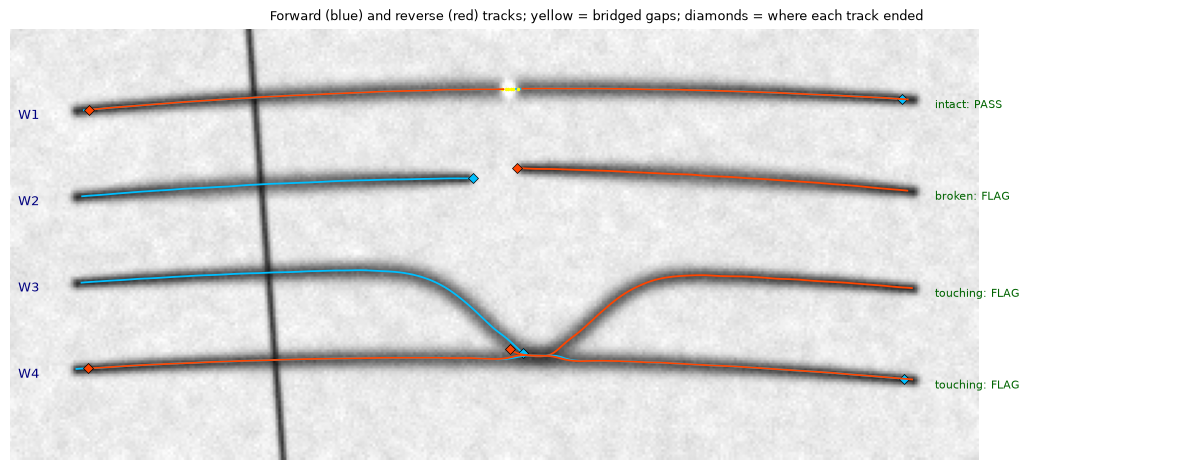

W1 (intact): PASS: both tracks reached the opposite pad, agree within 0.0px; 1 bridged gap(s)
    fwd jump, wire hidden over 7px: offset -0.6px, kink -2 deg -> accepted
    rev jump, wire hidden over 7px: offset -0.7px, kink +2 deg -> accepted
W2 (broken): FLAG: fwd did not reach pad B (stopped at 172,55: discontinuity: hidden 17px, offset -3.1px, kink 2deg); rev did not reach pad A (stopped at 188,51: lost ridge); discontinuity at (180,53): wire hidden over 17px, offset -3.4px, kink 3deg
    fwd jump, wire hidden over 17px: offset -3.1px, kink +2 deg -> REJECTED
W3 (touching): FLAG: touching W4 near (194,121): centre distance 0.6px < wire width; fwd did not reach pad B (stopped at 190,120: lost ridge); rev did not reach pad A (stopped at 185,118: discontinuity: hidden 12px, offset 6.1px, kink 42deg); discontinuity at (188,120): wire hidden over 5px, offset 3.6px, kink -36deg
    rev jump, wire hidden over 12px: offset +6.1px, kink +42 deg -> REJECTED
W4 (touching): FLAG: passes 1.1px 

In [39]:
def demo_scene(H=160, W=360, seed=3):
    """Deterministic illustration in the coaxial look: a white background (flat,
    diffuse areas clipped to white), black wires, and a thin black line from the
    tilted silicon edge crossing all of them.
    W1 intact: blurred toward its apex, where a specular spot turns it white;
    W2 broken mid-span (the far piece is displaced and rotated about its pad);
    W3 bows into W4 until they touch (a short)."""
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:H, 0:W]
    img = np.clip(0.92 + 0.1 * gaussian_filter(rng.normal(size=(H, W)), 2), 0, 1)   # faint texture
    ww = 3.5                                                   # wire FWHM, px

    def darken(img, pts, amp=0.85):
        d, i = cKDTree(pts).query(np.column_stack([xx.ravel(), yy.ravel()]))
        s = np.linspace(0, 1, len(pts))[i]
        sig = ww / 2.355 * (1 + 0.8 * np.sin(np.pi * s))       # defocus toward the apex
        a = amp * (1 - 0.3 * np.sin(np.pi * s))
        att = (a * np.exp(-d**2 / (2 * sig**2))).reshape(H, W)
        return img * (1 - att) + 0.05 * att

    def arc(p0, p1, bow, n=400):
        s = np.linspace(0, 1, n)[:, None]
        p0, p1 = np.asarray(p0, float), np.asarray(p1, float)
        nrm = np.array([-(p1 - p0)[1], (p1 - p0)[0]]) / np.linalg.norm(p1 - p0)
        return p0 + s * (p1 - p0) + 4 * bow * s * (1 - s) * nrm

    pads = {'W1': ((25, 30), (335, 26)), 'W2': ((25, 62), (335, 60)),
            'W3': ((25, 94), (335, 96)), 'W4': ((25, 126), (335, 130))}
    w1 = arc(*pads['W1'], -6)
    img = darken(img, w1)
    p = w1[np.argmin(np.abs(w1[:, 0] - 185))]                  # specular spot at W1's apex:
    t = w1[np.argmin(np.abs(w1[:, 0] - 186))] - p
    t /= np.linalg.norm(t)
    u, v = (xx - p[0]) * t[0] + (yy - p[1]) * t[1], -(xx - p[0]) * t[1] + (yy - p[1]) * t[0]
    spot = np.clip(1.6 * np.exp(-u**2 / (2 * 2.0**2) - v**2 / (2 * 3.0**2)), 0, 1)
    img = img * (1 - spot) + spot                              # the wire turns white
    w2 = arc(*pads['W2'], -6)
    left, right = w2[w2[:, 0] < 170], w2[w2[:, 0] > 190]       # 20 px gap
    phi = 3.5 / np.hypot(*(right[0] - pads['W2'][1]))          # far end rotates about pad B
    R = np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]])
    right = (right - pads['W2'][1]) @ R.T + pads['W2'][1]
    img = darken(darken(img, left), right)
    w4 = arc(*pads['W4'], -6)
    w3 = arc(*pads['W3'], -6)
    s = np.linspace(0, 1, len(w3))
    pull = np.exp(-((s - 0.55) / 0.09)**2)[:, None]            # W3 bows into W4
    w3 = w3 + pull * (w4 - w3) * (1 - 0.6 * ww / np.linalg.norm(w4 - w3, axis=1, keepdims=True))
    img = darken(darken(img, w3), w4)
    edge = np.exp(-((xx - 95 - 0.08 * (yy - H / 2))**2) / (2 * 1.0**2))   # tilted silicon edge
    img = img * (1 - 0.8 * edge) + 0.05 * 0.8 * edge
    img = np.clip(img + rng.normal(0, 0.02, (H, W)), 0, 1)
    return img, pads, ww, {'W1': 'intact', 'W2': 'broken', 'W3': 'touching', 'W4': 'touching'}


def draw_tracks(ax, rd, lw=1.3):
    """Forward track blue, reverse track red, bridged gaps yellow, ends as diamonds."""
    for key, col in (('fwd', 'deepskyblue'), ('rev', 'orangered')):
        c = rd[key]
        s = c['smooth'][:, :2] * rd['scale']
        tr = s.copy()
        tr[c['coast']] = np.nan
        ax.plot(tr[:, 0], tr[:, 1], '-', color=col, lw=lw)
        ax.plot(s[c['coast'], 0], s[c['coast'], 1], '.', color='yellow', ms=3)
        ax.plot(*s[-1], 'D', color=col, ms=5, mec='k', mew=0.5)


demo_img, demo_pads, demo_w, demo_truth = demo_scene()
demo_out, demo_touches = assess_board(demo_img, demo_pads, demo_w, polarity='dark')

fig, ax = plt.subplots(figsize=(12, 5.6))
ax.imshow(demo_img, cmap='gray', vmin=0, vmax=1)
for nm, rd in demo_out.items():
    draw_tracks(ax, rd)
    pa, pb = demo_pads[nm]
    ax.text(pa[0] - 22, pa[1] + 3, nm, color='navy')
    ax.text(pb[0] + 8, pb[1] + 3, f"{demo_truth[nm]}: {'PASS' if rd['ok'] else 'FLAG'}",
            color='darkgreen' if rd['ok'] == (demo_truth[nm] == 'intact') else 'red', fontsize=8)
ax.set_xlim(0, demo_img.shape[1] + 75)
ax.set_title('Forward (blue) and reverse (red) tracks; yellow = bridged gaps; diamonds = where each track ended')
ax.axis('off')
plt.tight_layout()
plt.show()

for nm, rd in demo_out.items():
    print(f'{nm} ({demo_truth[nm]}): {rd["verdict"]}')
    for key in ('fwd', 'rev'):
        for j in rd[key]['tracker'].jumps:
            print(f"    {key} jump, wire hidden over {j['hidden'] * rd['scale']:.0f}px: "
                  f"offset {j['lateral'] * rd['scale']:+.1f}px, "
                  f"kink {j['kink']:+.0f} deg -> {'accepted' if j['ok'] else 'REJECTED'}")

All four wires cross the black silicon-edge line without losing track: only a few patch columns see it, and the per-column background absorbs it.

The forward and reverse tracks of **W1** both coast through the specular spot and pick up the wire on the far side, about 7 px later. Both jumps are accepted: the offset is below 1 px and the kink about 2°, so the far side continues the near side. Both tracks reach the opposite pad and agree, and W1 passes.

For **W2** the forward track reaches the break and tries to jump it. The wire is missing over 17 px, far longer than a specular spot, and the far piece is about 3 px off the line the near side points along, so the jump is rejected and the track ends. The reverse track loses the wire at the other side of the break. The two tracks stop on either side of the break and never meet: FLAG.

**W3** bows into **W4**. W3's tracks stop at the contact: one loses the ridge where the two wires merge, and the other's jump across the merged stretch is rejected (kink of about 40°). W4's own tracks follow W4 all the way and agree, so W4 on its own would pass. It is flagged by the board-level rules only. W3's tracked line comes within a fraction of a pixel of W4's (the two lines getting too close is the only signal here), and W4 passes right next to the point where W3's tracking failed.

The next cell zooms into the forward jumps of W1 and W2. It shows the tracked points used on each side of the gap (blue: before, red: after) and the quadratic fit extrapolated to the middle of the gap. This is the whole content of the continuity test.

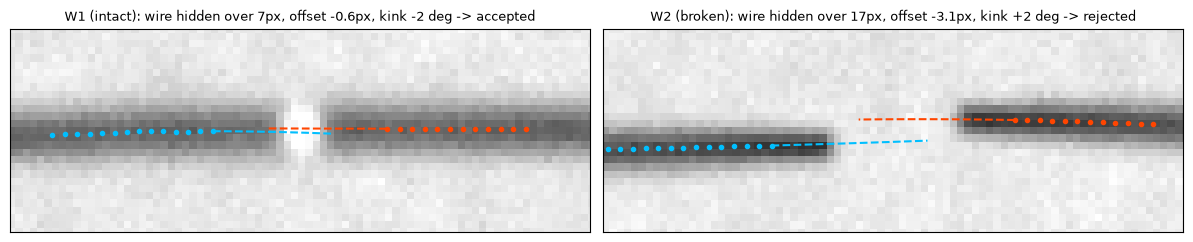

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, (nm, key) in zip(axes, (('W1', 'fwd'), ('W2', 'fwd'))):
    trk = demo_out[nm][key]['tracker']
    S = demo_out[nm]['scale']
    j = trk.jumps[0]                   # the points the test used: near side, far side
    ax.imshow(demo_img, cmap='gray', vmin=0, vmax=1)
    for pts, col in ((j['pa'], 'deepskyblue'), (j['pb'], 'orangered')):
        e, t, k = end_geometry(pts)
        arc = np.array([arc_extrapolate(e, t, k, s)[0] for s in np.linspace(0, j['gap'] / 2 + 4, 20)])
        ax.plot(pts[:, 0] * S, pts[:, 1] * S, 'o', color=col, ms=3)
        ax.plot(arc[:, 0] * S, arc[:, 1] * S, '--', color=col, lw=1.5)
    c = j['where'] * S
    ax.set_xlim(c[0] - 40, c[0] + 40)
    ax.set_ylim(c[1] + 14, c[1] - 14)
    ax.set_title(f"{nm} ({demo_truth[nm]}): wire hidden over {j['hidden'] * S:.0f}px, offset {j['lateral'] * S:+.1f}px, "
                 f"kink {j['kink']:+.0f} deg -> {'accepted' if j['ok'] else 'rejected'}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

<a id="10"></a>
## 10. Regression tests

The regression set consists of five synthetic images. For each wire, the expected pad positions were measured from the image, as a bonding program would provide them (inset from the image border where a wire runs off the image), and the expected verdict is given:

| Image | Content | Expected |
|---|---|---|
| test1 | one straight wire | intact |
| test2 | five wires, one oblique | all intact |
| test3 | seven horizontal and one diagonal wire crossing a vertical line (the silicon edge); two of the wires are only 16 px apart | all intact |
| test4 | curved wires; the third is broken; the fourth crosses the silicon-edge line | W3 broken |
| Test5 | as test4 with the curvature flipped (camera azimuth) | W3 broken |

Each image is assessed as a board: all of its wires together, with the switched-wire and touching checks included.

In [41]:
L, R = 12, 987      # pads inset from the 1000 px border where a wire leaves the image
REGRESSION = {
    'test1': dict(width=10, wires=[((L, 438), (R, 438), True)]),
    'test2': dict(width=10, wires=[((L, 136), (R, 136), True), ((L, 386), (R, 386), True),
                                   ((L, 562), (R, 562), True), ((L, 726), (R, 726), True),
                                   ((L, 901), (R, 823), True)]),
    'test3': dict(width=10, wires=[((L, 106), (R, 106), True), ((L, 228), (R, 228), True),
                                   ((L, 362), (957, 362), True), ((L, 406), (R, 406), True),
                                   ((L, 530), (972, 530), True), ((L, 546), (R, 546), True),
                                   ((L, 747), (R, 900), True), ((L, 942), (R, 944), True)]),
    'test4': dict(width=7, wires=[((L, 84), (R, 84), True), ((L, 259), (R, 368), True),
                                  ((L, 424), (R, 497), False), ((L, 692), (R, 676), True)]),
    'Test5': dict(width=7, wires=[((38, 130), (923, 130), True), ((45, 221), (923, 234), True),
                                  ((41, 295), (918, 290), False), ((38, 629), (909, 660), True)]),
}


def run_regression(name):
    case = REGRESSION[name]
    img = load_test_image(name)
    pads = {f'W{k + 1}': (pa, pb) for k, (pa, pb, _) in enumerate(case['wires'])}
    out, _ = assess_board(img, pads, case['width'], polarity='bright')    # drawn white-on-black
    expected = {f'W{k + 1}': intact for k, (_, _, intact) in enumerate(case['wires'])}
    return img, pads, out, expected


def plot_regression(name, img, pads, out, expected):
    """Overview with both tracks, then, per wire, the distance between the two
    tracks along the wire and where each of them found wire (coverage bars)."""
    n = len(pads)
    fig = plt.figure(figsize=(12, 10 + 1.25 * n))
    gs = fig.add_gridspec(n + 1, 1, height_ratios=[10] + [1.25] * n)
    ax = fig.add_subplot(gs[0])
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    for nm, rd in out.items():
        draw_tracks(ax, rd)
        good = rd['ok'] == expected[nm]
        ax.text(pads[nm][0][0] + 5, pads[nm][0][1] - 14, f"{nm}: {'PASS' if rd['ok'] else 'FLAG'}",
                color='lime' if rd['ok'] else 'red', fontsize=8, weight='bold',
                bbox=dict(facecolor='black', alpha=0.6, pad=1, lw=0))
    ax.set_title(f'{name}: forward (blue) and reverse (red) tracks')
    ax.axis('off')
    for row, (nm, rd) in enumerate(out.items()):
        a2 = fig.add_subplot(gs[row + 1])
        pa, pb = (np.asarray(p, float) for p in pads[nm])
        t = (pb - pa) / np.linalg.norm(pb - pa)
        S = rd['scale']
        along = lambda p: (p * S - pa) @ t
        f, r = rd['fwd'], rd['rev']
        fs, rs = f['smooth'][:, :2], r['smooth'][:, :2]
        if len(fs) > 1 and len(rs) > 1:
            a2.plot(along(fs), S * polyline_dist(fs, rs), color='deepskyblue', lw=1, label='fwd to rev track')
            a2.plot(along(rs), S * polyline_dist(rs, fs), color='orangered', lw=1, label='rev to fwd track')
        for c, col, y in ((f, 'deepskyblue', -0.8), (r, 'orangered', -1.6)):
            u = along(c['smooth'][:, :2])
            a2.plot(u, np.full(len(u), y), '|', color=col, ms=4)
            a2.plot(u[c['coast']], np.full(c['coast'].sum(), y), '|', color='gold', ms=4)
        a2.axvline(0, color='lime', lw=0.8)
        a2.axvline(np.linalg.norm(pb - pa), color='lime', lw=0.8)
        a2.set_ylim(-2.2, 3)
        a2.set_ylabel('px')
        a2.set_title(f"{nm} (expected {'intact' if expected[nm] else 'BROKEN'}): {rd['verdict'][:140]}",
                     loc='left', fontsize=8, color='green' if rd['ok'] == expected[nm] else 'red')
        if row == 0:
            a2.legend(fontsize=7, loc='upper center', ncol=2)
    a2.set_xlabel('position along the wire from pad A (px). Bars: where the fwd (upper) and rev (lower) '
                  'track found wire; gold = bridged gap. Green lines: pads.')
    plt.tight_layout()
    plt.show()


results = {name: run_regression(name) for name in REGRESSION}
print('regression images assessed')

regression images assessed


In each figure below, the upper panel shows both tracks on the image. Each row below it belongs to one wire:

* **Curves:** the distance from each track to the other one along the wire. They sit at zero wherever the two independent tracks coincide. They rise only at the very ends, where one track stops at its target pad while the other started a few pixels inside the wire.
* **Bars:** where each track found wire.

For the broken wires the bars show two tracks that stop on either side of the break. The forward and reverse tracks never meet.

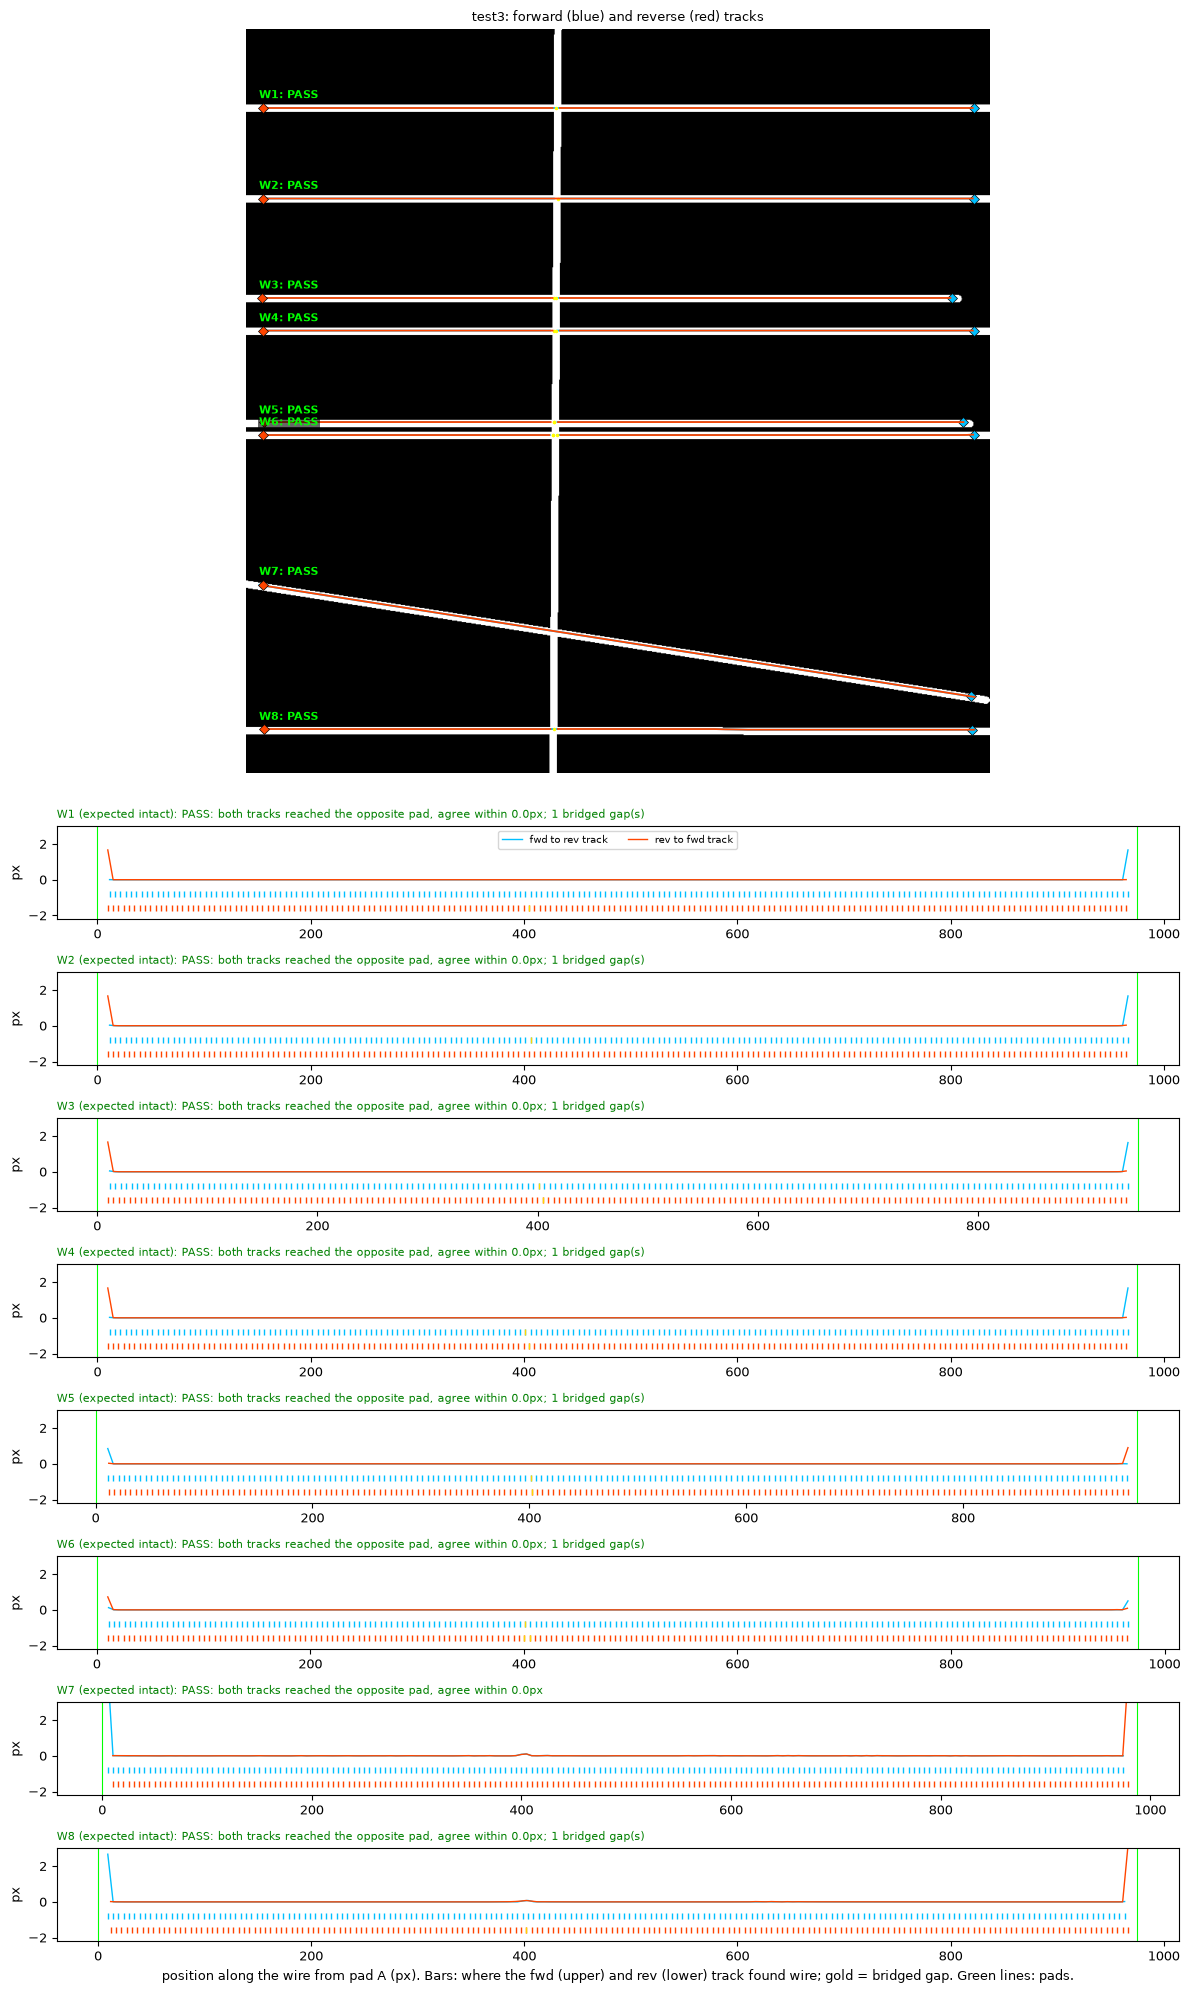

In [42]:
plot_regression('test3', *results['test3'])

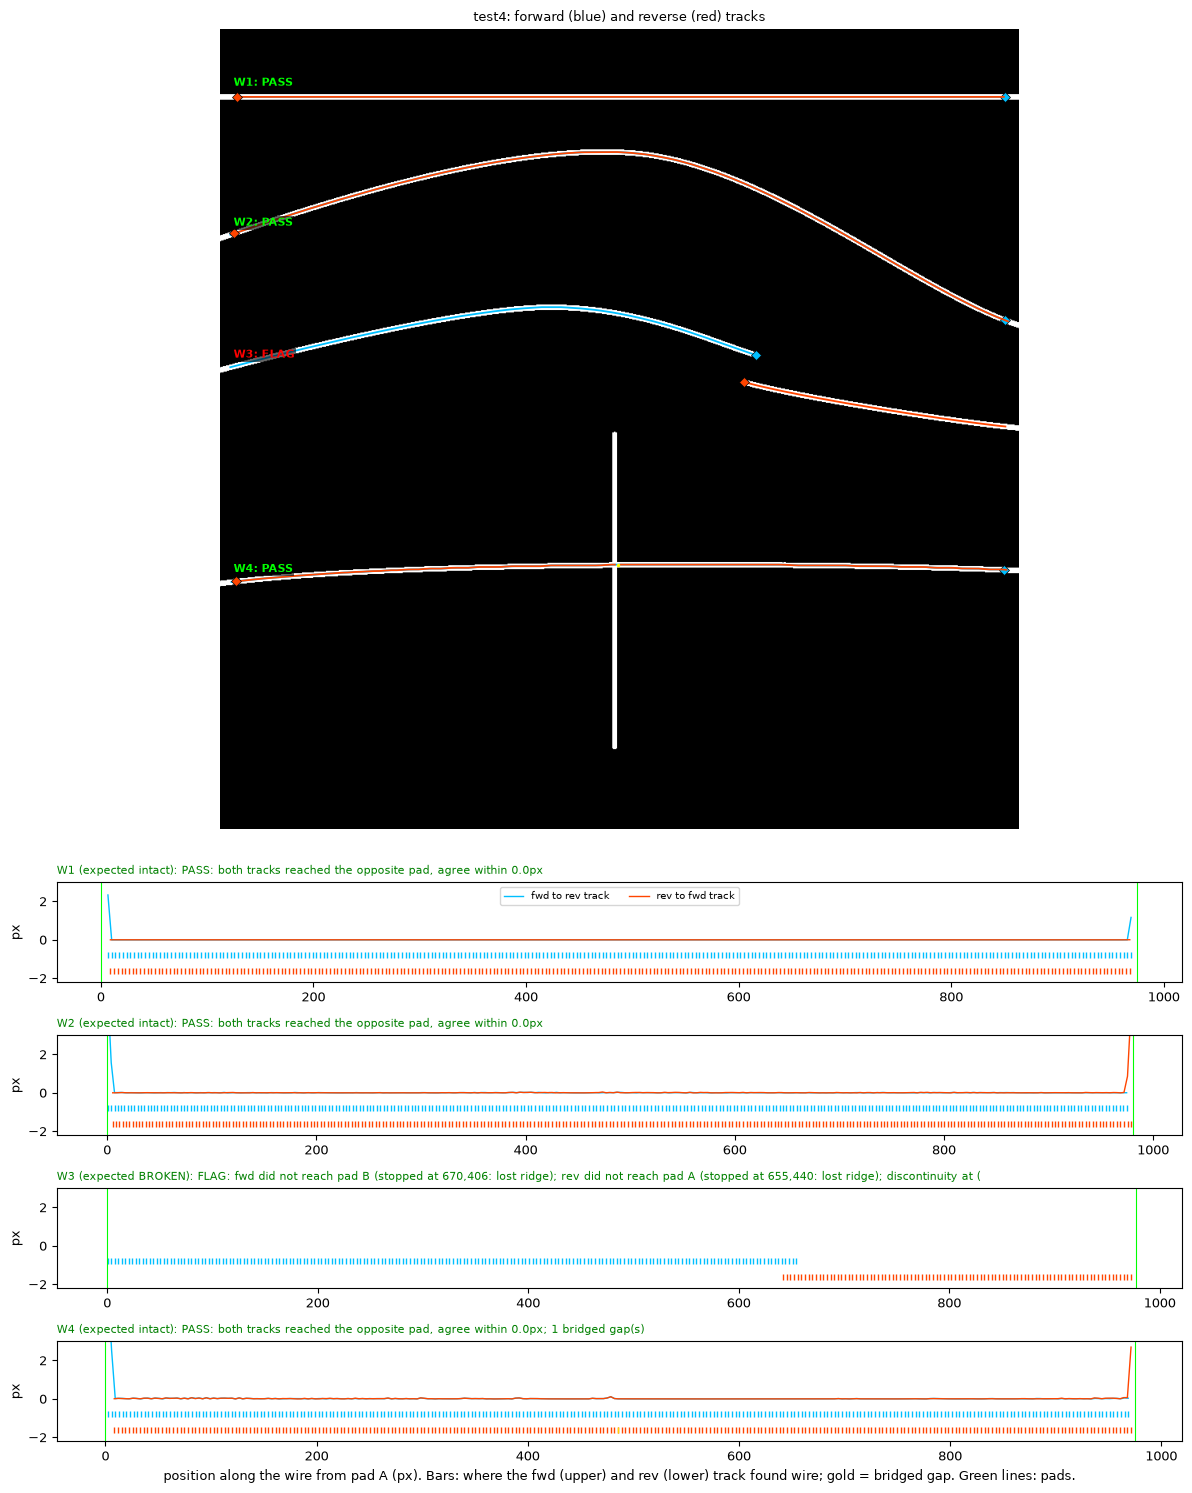

In [43]:
plot_regression('test4', *results['test4'])

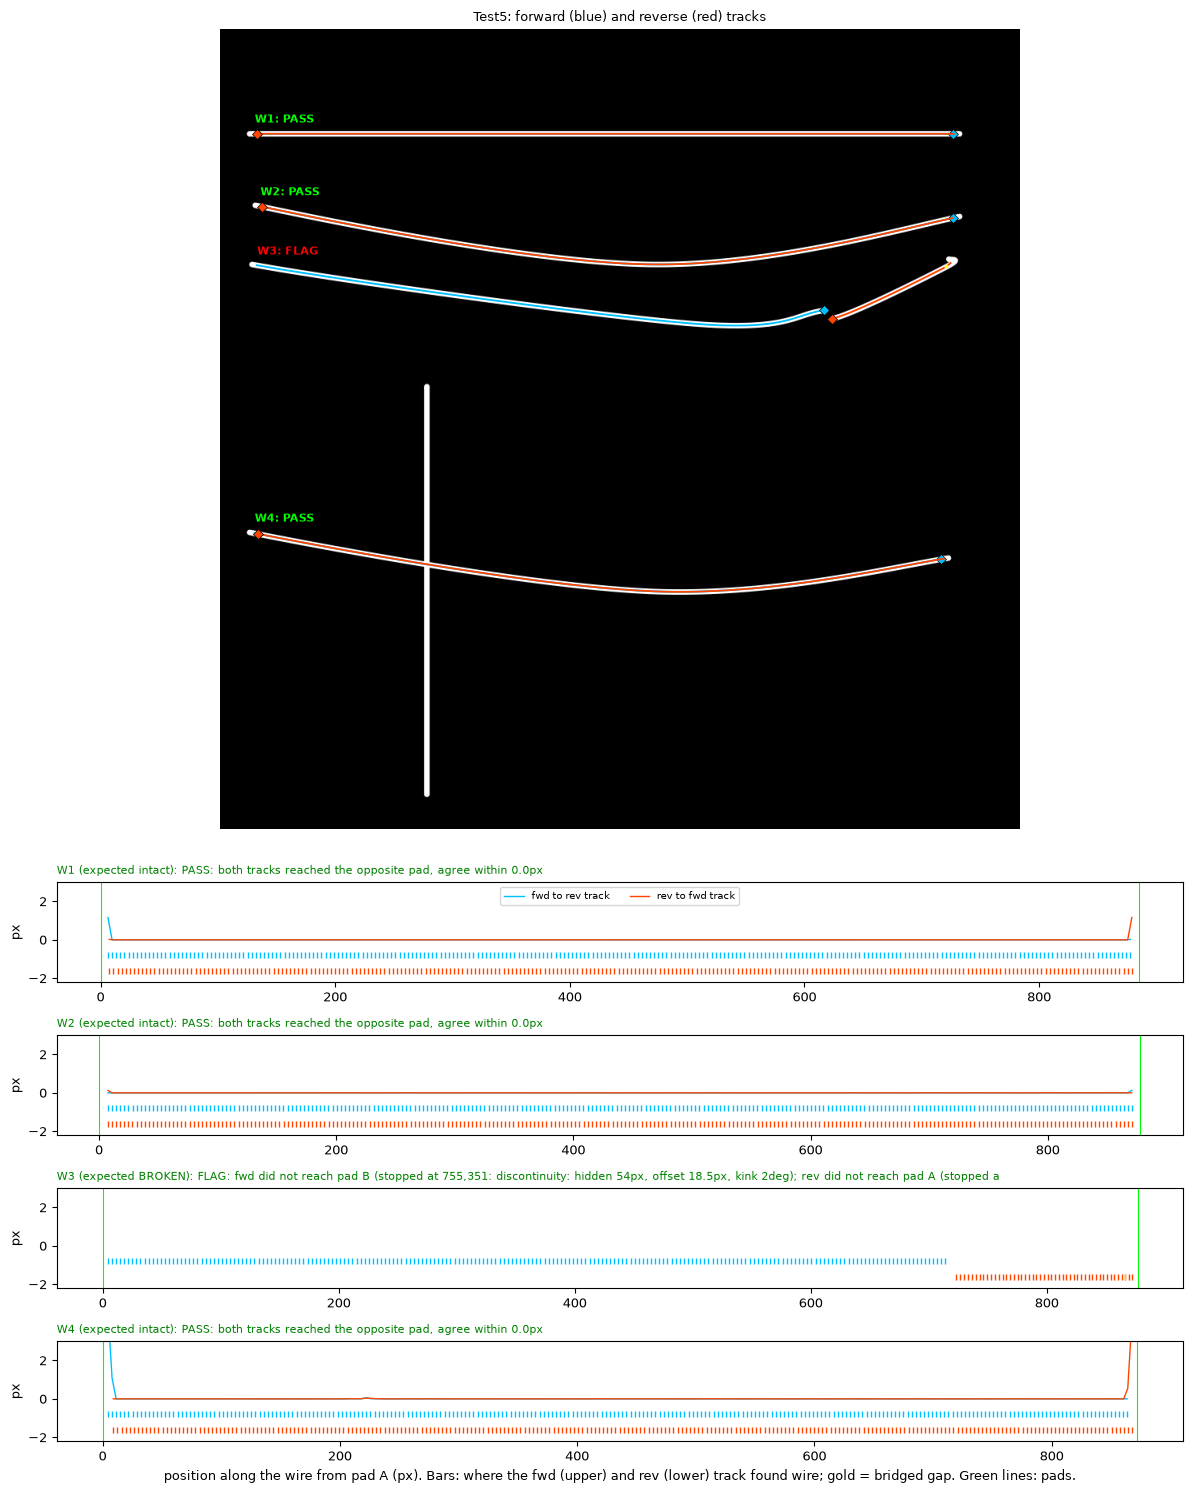

In [44]:
plot_regression('Test5', *results['Test5'])

In [45]:
print(f"{'image':6s} {'wire':4s} {'expected':9s} {'verdict':7s}  detail")
n_ok = n_all = 0
for name, (img, pads, out, expected) in results.items():
    for nm, rd in out.items():
        good = rd['ok'] == expected[nm]
        n_ok += good
        n_all += 1
        print(f"{name:6s} {nm:4s} {'intact' if expected[nm] else 'BROKEN':9s} {'PASS' if rd['ok'] else 'FLAG':7s}"
              f"{'' if good else '  <-- WRONG'}  {rd['verdict'][:110]}")
print(f'\n{n_ok}/{n_all} wires received the expected verdict')
assert n_ok == n_all

image  wire expected  verdict  detail
test1  W1   intact    PASS     PASS: both tracks reached the opposite pad, agree within 0.0px
test2  W1   intact    PASS     PASS: both tracks reached the opposite pad, agree within 0.0px
test2  W2   intact    PASS     PASS: both tracks reached the opposite pad, agree within 0.0px
test2  W3   intact    PASS     PASS: both tracks reached the opposite pad, agree within 0.0px
test2  W4   intact    PASS     PASS: both tracks reached the opposite pad, agree within 0.0px
test2  W5   intact    PASS     PASS: both tracks reached the opposite pad, agree within 0.0px
test3  W1   intact    PASS     PASS: both tracks reached the opposite pad, agree within 0.0px; 1 bridged gap(s)
test3  W2   intact    PASS     PASS: both tracks reached the opposite pad, agree within 0.0px; 1 bridged gap(s)
test3  W3   intact    PASS     PASS: both tracks reached the opposite pad, agree within 0.0px; 1 bridged gap(s)
test3  W4   intact    PASS     PASS: both tracks reached the o

<a id="11"></a>
## 11. Development benchmark

During development the method was also evaluated on randomly generated boards in the coaxial look. The generator is not part of this notebook. Each board has 5–8 black wires on a white, faintly textured background, fanning from one row of pads to another, with the following features:

* wire width 3–4.5 px, and depth-of-field blur toward the apex;
* on 80 % of the wires, a white specular spot 2–6 px long near the apex;
* a thin black silicon-edge line crossing all wires;
* uneven illumination and sensor noise.

About a third of the wires carry a defect:

* **broken:** a 10–35 px gap, with the far piece rotated about its pad so that its end moves 3–10 px (a real broken wire, being under tension, usually moves much further);
* **lifted:** the last 15–30 px near one pad missing, and the remaining end bent away;
* **touching:** a wire bent into its neighbour until their centres are closer than one wire width.

When a defect lands on a neighbour, that neighbour is also labelled touching. Wires whose centres come within 1–1.5 wire widths of a neighbour are ambiguous after blur; they are labelled *near* and not scored.

Results for two independent sets of 40 boards:

| | set A | set B |
|---|---|---|
| defective wires flagged (broken / lifted / touching) | 30/30 · 31/31 · 32/32 | 26/26 · 38/38 · 45/45 |
| **missed defects (false negatives)** | **0** | **0** |
| intact wires flagged (false positives) | 16 / 159 | 23 / 142 |
| … of which only next to a defective wire | 13 | 15 |
| … flagged on their own account | 3 (1.9 %) | 8 (5.6 %) |

No defective wire was missed. About 10–16 % of the intact wires were flagged for inspection. In this benchmark about a third of all wires are defective, far more than on a production line. Most of these flags fall on wires that sit next to a defective one. The rate that carries over to a line with rare defects is the last row: 2–6 % of intact wires flagged on their own account, mostly specular spots whose jump just exceeded a tolerance.

<a id="12"></a>
## 12. Discussion and limitations

**What the method relies on.** It relies on three things. The expected pad positions come from the bonding program. The wire width is known. And an intact wire is a smooth curve: where it is hidden, the visible parts on either side continue each other. The verdict is deliberately asymmetric. A wire passes only when two independent tracks, started from opposite ends, both reach their target and coincide. Any failure along the way is reported with its location and reason.

**Limitations.**

* **Tolerances are calibrated, not derived.** They are set in working pixels (wire FWHM ≈ 3 px): the kink limit (15°), the lateral offset limit (1.5 px + 5 % of the gap), the hidden-length limit (10 px, about three wire widths) and the coasting range (30 px). They were chosen on synthetic data and should be re-checked on real images of the target setup.
* **A break without offset or kink cannot be told apart from a specular spot by geometry.** A break whose two ends happen to stay collinear shows neither signature. It is caught only if the wire is missing over more than about three wire widths, which is longer than a specular spot. In practice this case is very unlikely: a bonded wire is bent and under tension like a spring, so when it breaks the ends move far from their original path. The synthetic breaks used here (ends displaced by only 3–10 px) are close to the worst case.
* **Zero missed defects is bought with false positives.** The board-level rules (tracked lines closer than a wire width; any wire near an unexplained failure) are deliberately generous. On the benchmark they flag a noticeable fraction of intact wires, most of them next to a genuinely defective wire. On a production line, where defects are rare, those neighbour flags become rare too.
* **Wires at 1–1.5 wire widths are ambiguous.** Such wires merge visually after blur, and the method flags them. For shorts this is the safe side, but it is not a measurement of contact.
* **No real inspection images are shown here.** They cannot be shared. In real coaxial images, the greyish diffuse parts of the background should be clipped to white before tracking, so that the only dark structures left are the wires and the silicon edge.

<a id="13"></a>
## 13. Bibliography

[Steger, 1998] Carsten Steger. "An Unbiased Detector of Curvilinear Structures." *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 20(2):113–125, 1998. [DOI](https://doi.org/10.1109/34.659930)

[Kalman, 1960] Rudolf E. Kalman. "A New Approach to Linear Filtering and Prediction Problems." *ASME Journal of Basic Engineering*, 82(1):35–45, 1960. [DOI](https://doi.org/10.1115/1.3662552)

[Rauch et al., 1965] H. E. Rauch, F. Tung and C. T. Striebel. "Maximum Likelihood Estimates of Linear Dynamic Systems." *AIAA Journal*, 3(8):1445–1450, 1965. [DOI](https://doi.org/10.2514/3.3166)

[Bell & Cathey, 1993] Bradley M. Bell and Frederick W. Cathey. "The Iterated Kalman Filter Update as a Gauss–Newton Method." *IEEE Transactions on Automatic Control*, 38(2):294–297, 1993. [DOI](https://doi.org/10.1109/9.250476)